# Lab work # 1

> Student name    - Rodion

> Student surname - Ostapenko

> Group           - CS-32


# Task description

### Overall work description

The work will contain 2 main parts:
1. In the first part you'll build intuition behind using various regression models using only artificially generated (with noise & outliers) data. I've generated 2 options with `f(x) = A*sin(x) + B` and `f(x) = a*x + b` functions. (you free to add more complex functions (even more dimensional).
2. In the second part you'll solve regression problem on the real data.

Do NOT forget to change your `STUDENT_NO` -- this variable defines random state (it just makes experimental data for every one slighty different).

Do NOT forget to set you contact data in the top cell.


### I. Experiments on artificially generated data:

1. Manually tune linear model by changing `a` and `b` weights of it. Observe position of the line and values of loss function.
2. **More advanced task** (+2 point): modify my code to work with more complex functions as regression models (linear, polynomial, sin, cos, and their combination). Feel free to use as complex function as you could found. Generate some random non-linear data and use your function to manually adjust its weights.
3. Play with default regression methods from `sklearn` library on non-linear data. Search, llm-prompt information on each model to understand how to make the model fit the data without overfitting.


### II. Experiments on real data. (you can keep it in this notebook or in a separate one).

1. Choose any DataSet you like for you experiments (if you've chosen the same, consider that work must differ, otherwise both students will get 0 points for work).
2. Choose the top-3 methods (from `sklearn` library, or you can use other libraries (like `xgboost`) from the previous part.
2. Solve the regression problem in the same manner, as you used for.
    1. Load the data
    2. Do data visualization: correlation, feature distribution, etc.
    3. Do data analysis
    4. Do data correction
    5. Prepare data on usage with ML model: train, validation if necessary, test split; data convertion (to fix distribution or change data type to numeric); remove outliers.
    6. Tune hyperparameters of your model to get the best one.
    7. Train & test the final version of the model. Do conclusion.
3. Your main goal is tune hyperparameters of the chosen models.
4. Examples and template you can find in `ML_basic_course/lab_works/lab2/lab_2_example_plus_task.ipynb`. Or in [my GitHub repo's folder](https://github.com/VolDonets/ML_basics_course/tree/master/lab_works/lab_2)
5. Use that notebook as template, but remember your main goal is to tune hyperparameters of chosen models.

### III. Important.

1. Students, who solved the problem in a single code cell will get 0 points for your work. It's hard to work with your messy code, we have limited time. Use this notebook as your template, create as many cells as you need. Also you can conduct experiments in .py files but in that case prepare normal report.
2. Experiments means you have multiple cells with EXPERIMENTS and your CONCLUSION after that.
3. You can have multiple notebooks if you need, but name it correctly and add `ReadMe.md`.


## Proposition of the real data for experiments

0. Your own data (the main idea here that target value is a number, not a class)
1. [Taxi Price Regression 🚕](https://www.kaggle.com/datasets/denkuznetz/taxi-price-prediction)
2. [Car Pricing Regression Dataset](https://www.kaggle.com/datasets/amjadzhour/car-price-prediction)
3. [Second Hand Car Price Prediction
](https://www.kaggle.com/datasets/sujithmandala/second-hand-car-price-prediction)
4. [Indian Rental House Price](https://www.kaggle.com/datasets/bhavyadhingra00020/india-rental-house-price)
5. *** [Google Stock Prediction](https://www.kaggle.com/datasets/shreenidhihipparagi/google-stock-prediction) -- this is stock data, so probably for prediction you'll need the previous values (for previous days, or day).
6. [Forest Fire Regression](https://www.kaggle.com/datasets/nimapourmoradi/forest-fire-regression)
7. [California House Price](https://www.kaggle.com/datasets/shibumohapatra/house-price)
8. *** [Asteroid Dataset](https://www.kaggle.com/datasets/sakhawat18/asteroid-dataset) -- this is hard problem, try to predict any continuous feature (like asteroid radius).
9. [Salary Prediction](https://www.kaggle.com/datasets/thedevastator/jobs-dataset-from-glassdoor)
10. [January Flight Delay Prediction](https://www.kaggle.com/datasets/divyansh22/flight-delay-prediction)
11. [Restaurants Revenue Prediction](https://www.kaggle.com/datasets/mrsimple07/restaurants-revenue-prediction)
12. [Body Fat Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/body-fat-prediction-dataset)
13. [Furniture Price Prediction](https://www.kaggle.com/datasets/shawkyelgendy/furniture-price-prediction) 

In [294]:
STUDENT_NO = 20

# Import dependencies

In [295]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import re
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Helping functions

In [296]:
def generate_regression_data(
    n_samples=50, 
    n_features=1, 
    mode='linear', 
    noise=2.0, 
    n_outliers=5, 
    random_seed=42, 
    return_coef=False
):
    """
    Generates data for regression tasks, compatible with scikit-learn.

    :param n_samples: The total number of data points to generate.
    :param n_features: The number of features for the dataset.
    :param mode: The underlying pattern of the data. Can be 'linear' or 'nonlinear'.
    :param noise: The standard deviation of Gaussian noise added to the y-values.
    :param n_outliers: The number of outlier points to add to the dataset.
    :param random_seed: A seed for the random number generator for reproducibility.
    :param return_coef: If True, also returns the true coefficients of the generative model.
    :returns: A tuple (X, y) or (X, y, coefficients) if return_coef is True.
              X is the feature matrix of shape (n_samples, n_features).
              y is the target vector of shape (n_samples,).
              coefficients is a list.
    """
    
    np.random.seed(random_seed)

    X = np.random.rand(n_samples, n_features) * 10 - 5

    true_intercept = 0
    true_weights = np.zeros(n_features)
    
    if mode == 'linear':
        true_intercept = np.random.uniform(-3, 3)
        true_weights = np.random.uniform(-5, 5, size=n_features)
        y_true = np.dot(X, true_weights) + true_intercept
    elif mode == 'nonlinear':
        if n_features < 1:
            raise ValueError("Nonlinear mode requires at least 1 feature.")
        
        true_intercept = np.random.uniform(-15, 15)
        true_weights = np.random.uniform(-5, 5, size=n_features)
        
        y_true = true_weights[0] * 20 * np.sin(X[:, 0]*1.5) + true_intercept
        
        if n_features > 1:
             y_true += np.dot(X[:, 1:], true_weights[1:])
    elif mode == 'additional':
        if n_features != 1:
            raise ValueError("Additional mode requires exactly 1 feature.")
        
        a = np.random.uniform(1.0, 5.0)
        b = np.random.uniform(0.5, 2.0)
        c = np.random.uniform(0.5, 2.0)
        d = np.random.uniform(-np.pi, np.pi)
        e = np.random.uniform(-15, 15)
        
        true_intercept = e
        true_weights = np.array([a, b, c, d])
        
        # ! For additional task !: f(x) = a*sin(b * log_2(x * c) + d) + e
        x_term = np.abs(X[:, 0] * c)
        x_term = np.where(x_term == 0, 1e-5, x_term) # Prevent log2(0)
        
        y_true = a * np.sin(b * np.log2(x_term) + d) + e
        
    else:
        raise ValueError("Mode must be 'linear' or 'nonlinear' or 'additional'")

    y = y_true + np.random.normal(scale=noise, size=n_samples)

    if n_outliers > 0:
        outlier_indices = np.random.choice(n_samples, n_outliers, replace=False)
        outlier_offset = (np.random.rand(n_outliers) - 0.5) * 30 * (noise + 1)
        y[outlier_indices] += outlier_offset

    if return_coef:
        coefficients = np.append(true_weights, true_intercept)
        return X, y, coefficients
    else:
        return X, y

In [297]:
def plot_regression_model(
    X, 
    y, 
    weights=None,
    intercept=None, 
    nonlinear_params=None,
    title="Regression Model Visualization",
):
    """
    Visualizes regression data and model performance for both linear and nonlinear models.

    If the data has one feature:
      - Plots data points and the fitted curve (nonlinear) or line (linear).
    If the data has multiple features:
      - Plots the model's predicted vs. actual values.

    :param X: The feature matrix, shape (n_samples, n_features).
    :param y: The target vector, shape (n_samples,).
    :param weights: The model's feature weights (coefficients for linear or extra features).
    :param intercept: The model's intercept (for linear models).
    :param nonlinear_params: List containing weights for the nonlinear model.
    :param title: The title for the plot.
    :returns: None. Displays a matplotlib plot.
    """
    
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    n_features = X.shape[1]
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 7))

    nonlinear_provided = nonlinear_params is not None
    linear_provided = weights is not None and intercept is not None

    if n_features == 1:
        ax.scatter(X, y, c='cornflowerblue', alpha=0.7, edgecolors='k', label='Data Points')
        
        if nonlinear_provided:
            x_line = 0
            y_line = 0
            if len(nonlinear_params) == 2:
                a, b, = nonlinear_params
                
                x_line = np.linspace(X.min(), X.max(), 300)
                y_line = a * 20 * np.sin(x_line*1.5) + b
                
            elif len(nonlinear_params) == 5:
                a, b, c, d, e = nonlinear_params
            
                x_line = np.linspace(X.min(), X.max(), 300)
                x_term = np.abs(x_line * c)
                x_term = np.where(x_term == 0, 1e-5, x_term)
                y_line = a * np.sin(b * np.log2(x_term) + d) + e
            
            label = f'Nonlinear Model Curve'
            ax.plot(x_line, y_line, color='crimson', linewidth=2.5, label=label)
            ax.legend(fontsize=11)
            
        elif linear_provided:
            x_line = np.linspace(X.min(), X.max(), 200)
            y_line = x_line * weights[0] + intercept
            label = f'Linear Model: y = {weights[0]:.2f}x + {intercept:.2f}'
            ax.plot(x_line, y_line, color='crimson', linewidth=2.5, label=label)
            ax.legend(fontsize=11)

        ax.set_xlabel("Feature (X)", fontsize=12)
        ax.set_ylabel("Target (y)", fontsize=12)

    else: # n_features > 1
        if not nonlinear_provided and not linear_provided:
            print("Cannot visualize raw multi-feature data. Please provide model parameters to generate a plot.")
            plt.close(fig)
            return

        if nonlinear_provided:
            a, b, c, d, e = nonlinear_params
            
            x_term = np.abs(X[:, 0] * c)
            x_term = np.where(x_term == 0, 1e-5, x_term)
            y_pred = a * np.sin(b * np.log2(x_term) + d) + e
            
            if weights is not None:
                y_pred += np.dot(X[:, 1:], weights)
        else:
            y_pred = np.dot(X, weights) + intercept
        
        ax.scatter(y, y_pred, c='cornflowerblue', alpha=0.7, edgecolors='k')
        
        perfect_fit_line = np.linspace(min(y.min(), y_pred.min()), max(y.max(), y_pred.max()), 100)
        ax.plot(perfect_fit_line, perfect_fit_line, color='crimson', linestyle='--', linewidth=2.5, label='Perfect Fit (y_pred = y_true)')
        
        ax.set_xlabel("Actual Values (y_true)", fontsize=12)
        ax.set_ylabel("Predicted Values (y_pred)", fontsize=12)
        ax.legend(fontsize=11)

    ax.set_title(title, fontsize=14, weight='bold')
    plt.show()

In [298]:
def plot_sklearn_regression(model, X, y, title="Model Performance", step=0.01):
    """
    Visualizes the performance of a trained scikit-learn regression model.

    If X has one feature, it plots the data and the model's line point-by-point.
    If X has multiple features, it plots the model's predicted vs. actual values.

    :param model: A trained scikit-learn regressor object (e.g., LinearRegression, Ridge).
    :param X: The feature matrix, shape (n_samples, n_features).
    :param y: The true target vector, shape (n_samples,).
    :param title: The title for the plot.
    :param step: The precision delta for drawing the model's line in the 1D case.
    :returns: None. Displays a matplotlib plot.
    """
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    n_features = X.shape[1]
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 7))

    if n_features == 1:
        ax.scatter(X, y, c='cornflowerblue', alpha=0.6, edgecolors='k', label='Actual Data')
        
        # --- Updated Section ---
        x_min, x_max = X.min(), X.max()
        padding = (x_max - x_min) * 0.05
        
        # Create X-records point-by-point using the specified step/precision
        x_line = np.arange(x_min - padding, x_max + padding, step).reshape(-1, 1)
        
        # Get the corresponding y-values from the model
        y_line = model.predict(x_line)
        # --- End Updated Section ---
        
        ax.plot(x_line, y_line, color='crimson', linewidth=1.5, label='Model Prediction Line')
        ax.set_xlabel("Feature (X)", fontsize=12)
        ax.set_ylabel("Target (y)", fontsize=12)

    else: # Multi-feature case
        y_pred = model.predict(X)
        
        ax.scatter(y, y_pred, c='cornflowerblue', alpha=0.6, edgecolors='k')
        
        perfect_fit_line = np.linspace(min(y.min(), y_pred.min()), max(y.max(), y_pred.max()), 100)
        ax.plot(perfect_fit_line, perfect_fit_line, color='crimson', linestyle='--', linewidth=2, label='Perfect Fit')
        
        ax.set_xlabel("Actual Values", fontsize=12)
        ax.set_ylabel("Predicted Values", fontsize=12)

    ax.legend(fontsize=11)
    ax.set_title(title, fontsize=14, weight='bold')
    plt.show()

In [404]:
def evaluate_regression_model(y_true, X, model=None, model_name=None, weights=None, nonlinear_params=None, print_results=True):
    """
    Calculates and optionally prints metrics for a given regression model.

    Supports scikit-learn models, poly1d/coefficients, or custom nonlinear parameters 
    for the function: f(x) = a * sin(b * log2(x * c) + d) + e.

    :param y_true: The actual target values.
    :param X: The feature matrix.
    :param model: A trained sklearn model, a np.poly1d object, or a list of coefficients.
    :param weights: Additional feature weights (coefficients for multi-feature nonlinear/linear models).
    :param nonlinear_params: List containing [a, b, c, d, e].
    :param print_results: If True, prints the metrics to the console.
    :returns: A dictionary containing the calculated metrics.
    """
    
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    y_pred = None
    
    # --- Determine prediction method based on model/parameters provided ---
    if nonlinear_params is not None:
        if len(nonlinear_params) == 2:
            a, b = nonlinear_params
            
            y_pred = a * 20 * np.sin(X[:, 0]) + b
        
        if len(nonlinear_params) == 5:
            a, b, c, d, e = nonlinear_params
            # Ensure safe input for log2 (avoiding zero or negative values)
            x_term = np.abs(X[:, 0] * c)
            x_term = np.where(x_term == 0, 1e-5, x_term)
            
            y_pred = a * np.sin(b * np.log2(x_term) + d) + e
        
        # Add contributions from additional features if weights are provided
        if weights is not None:
            if X.shape[1] > 1:
                y_pred += np.dot(X[:, 1:], weights)
            else:
                print("Warning: Weights provided, but X has only 1 feature.")
                
    elif model is not None:
        if hasattr(model, 'predict'): # Handles scikit-learn models
            y_pred = model.predict(X)
        elif isinstance(model, (list, np.ndarray, np.poly1d)): # Handles weights and poly1d objects
            poly_model = np.poly1d(model)
            if X.shape[1] > 1:
                print("Warning: Manual weights are being applied to the first feature of X only.")
            y_pred = poly_model(X[:, 0])
        else:
            raise TypeError("Model type not supported. Please provide a scikit-learn model, list of weights, or nonlinear parameters.")
    else:
        raise ValueError("No model or nonlinear_params provided for evaluation.")

    # --- Calculate metrics ---
    metrics = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

    if print_results:
        if model_name is not None:
            print(f"----- 📈 {model_name} Evaluation -----")
        else:
            print("----- 📈 Model Evaluation -----")
        print(pd.Series(metrics).to_string(float_format="%.4f"))
        print("-----------------------------")

    return metrics

# Section 1: experiments on artificial data

**More advanced task** (+2 point): modify my code to work with more complex functions for regression (linear, polynomial, sin, cos, and their combination). Feel free to use as complex function as you could found.

## 1.1. Tuning manual Linear Regression 

Just change coefficients of the Linear model and observe changes in loss function

In [300]:
# Generating data
X_lin, y_lin = generate_regression_data(
    n_samples=250, 
    n_features=1, 
    mode='linear', 
    noise=5.0, 
    n_outliers=7, 
    random_seed=STUDENT_NO, 
    return_coef=False
)

----- 📈 Model Evaluation -----
MAE      45.4098
MSE    4259.2420
RMSE     65.2629
R2     -560.4481
-----------------------------


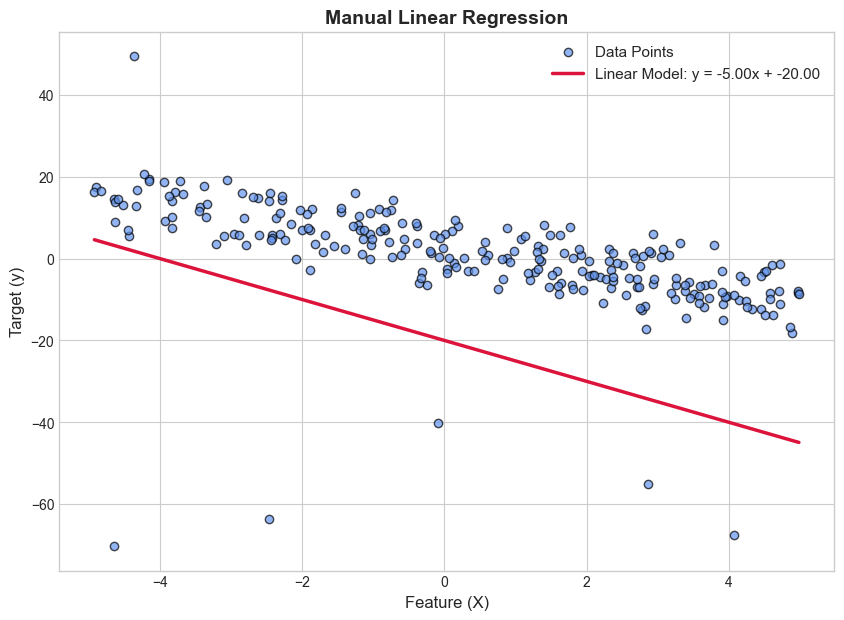

In [301]:
# Example of performing experiments
# f(x) = a*x + b
# ! For additional task !: f(x) = a*sin(b * log_2(x * c) + d) + e

lin_model_weights = [-5, -20]
evaluate_regression_model(X_lin, y_lin, model=lin_model_weights, print_results=True)
plot_regression_model(X_lin, y_lin, 
                      weights=[lin_model_weights[0], ], 
                      intercept=lin_model_weights[1],
                      title='Manual Linear Regression')

----- 📈 Model Evaluation -----
MAE      40.7554
MSE    3769.7760
RMSE     61.3985
R2     -495.9272
-----------------------------


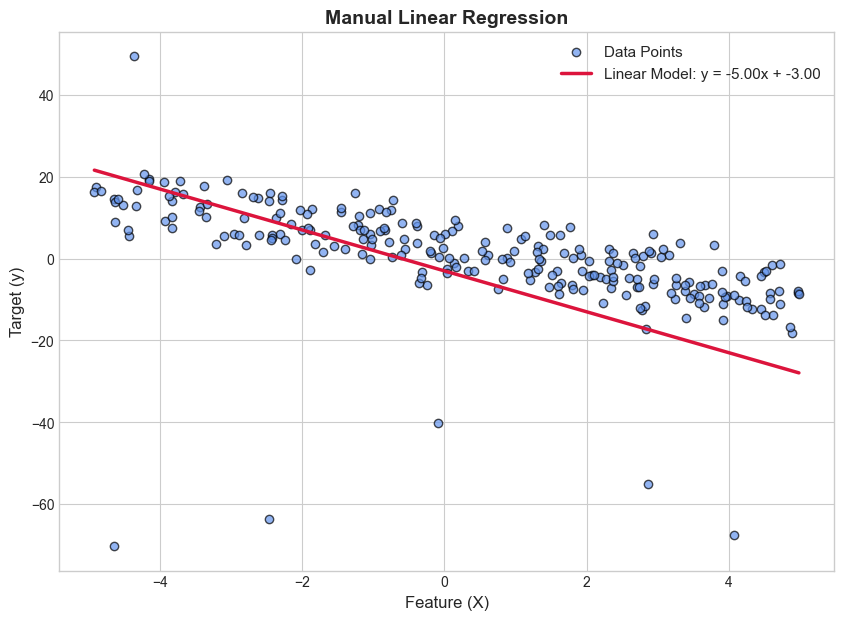

In [302]:
lin_model_weights = [-5, -3]
evaluate_regression_model(X_lin, y_lin, model=lin_model_weights, print_results=True)
plot_regression_model(X_lin, y_lin, 
                      weights=[lin_model_weights[0], ], 
                      intercept=lin_model_weights[1],
                      title='Manual Linear Regression')

----- 📈 Model Evaluation -----
MAE     2.4021
MSE     7.7838
RMSE    2.7899
R2     -0.0260
-----------------------------


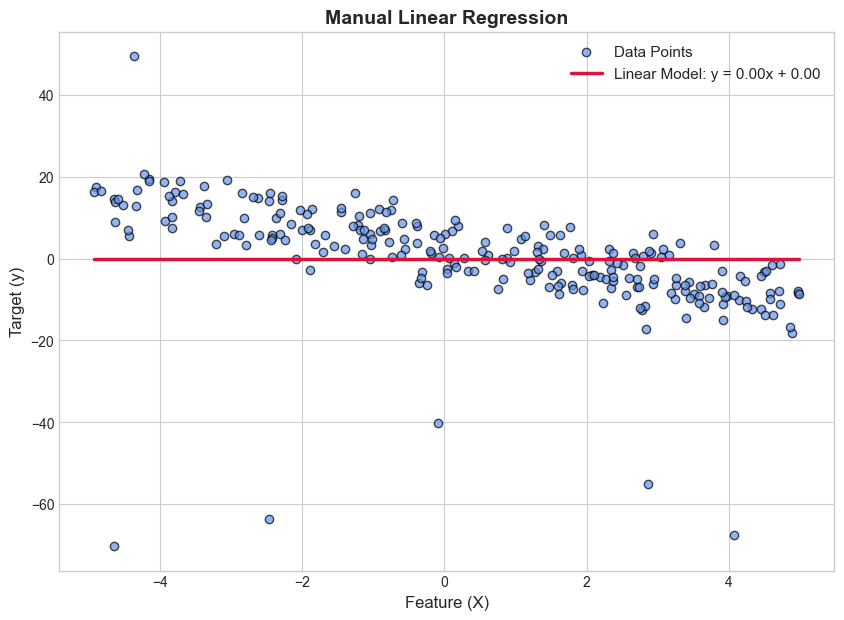

In [303]:
lin_model_weights = [0, 0]
evaluate_regression_model(X_lin, y_lin, model=lin_model_weights, print_results=True)
plot_regression_model(X_lin, y_lin, 
                      weights=[lin_model_weights[0], ], 
                      intercept=lin_model_weights[1],
                      title='Manual Linear Regression')

----- 📈 Model Evaluation -----
MAE       99.5555
MSE     9918.8751
RMSE      99.5935
R2     -1306.4940
-----------------------------


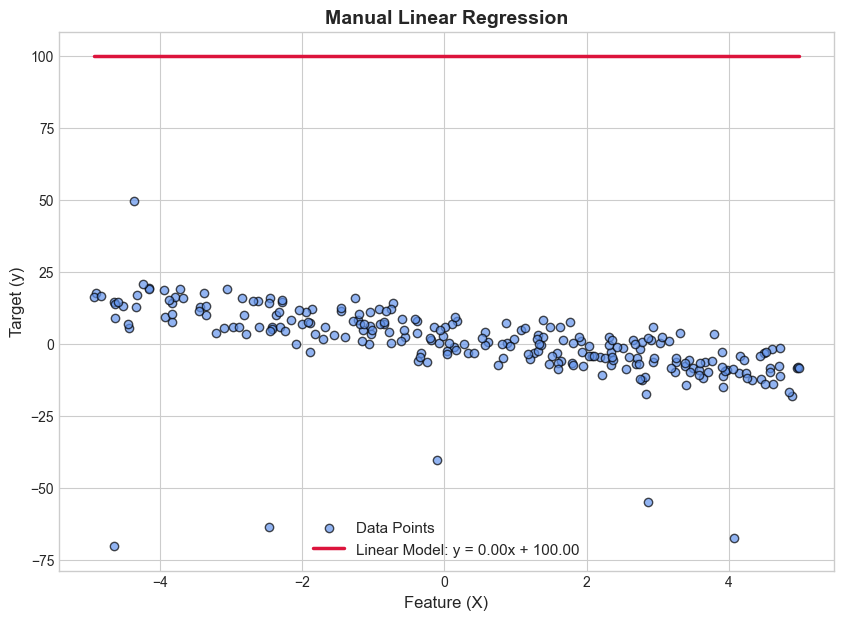

In [304]:
lin_model_weights = [0, 100]
evaluate_regression_model(X_lin, y_lin, model=lin_model_weights, print_results=True)
plot_regression_model(X_lin, y_lin, 
                      weights=[lin_model_weights[0], ], 
                      intercept=lin_model_weights[1],
                      title='Manual Linear Regression')

----- 📈 Model Evaluation -----
MAE      23.3047
MSE    1302.7579
RMSE     36.0937
R2     -170.7280
-----------------------------


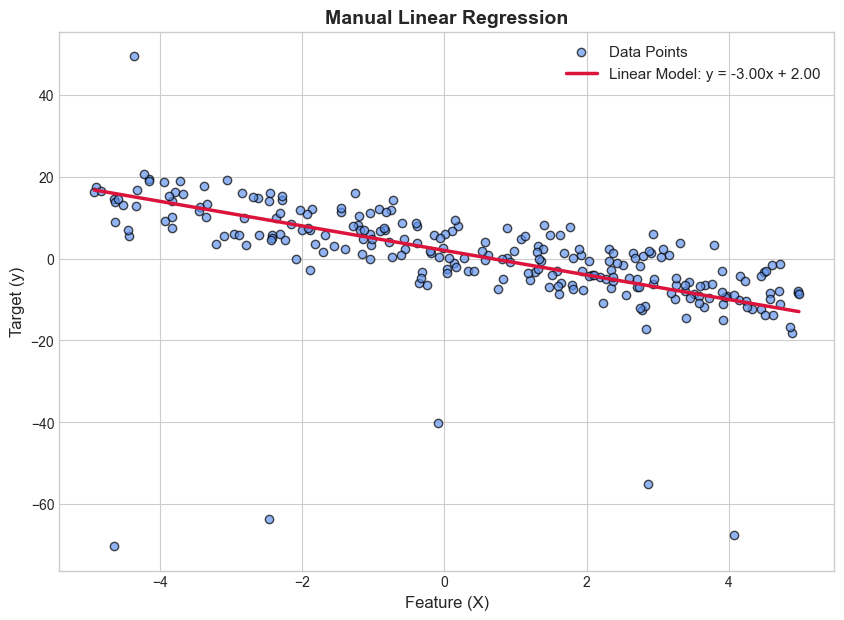

In [305]:
lin_model_weights = [-3, 2]
evaluate_regression_model(X_lin, y_lin, model=lin_model_weights, print_results=True)
plot_regression_model(X_lin, y_lin, 
                      weights=[lin_model_weights[0], ], 
                      intercept=lin_model_weights[1],
                      title='Manual Linear Regression')

----- 📈 Model Evaluation -----
MAE     4.1019
MSE    29.8022
RMSE    5.4591
R2     -2.9285
-----------------------------


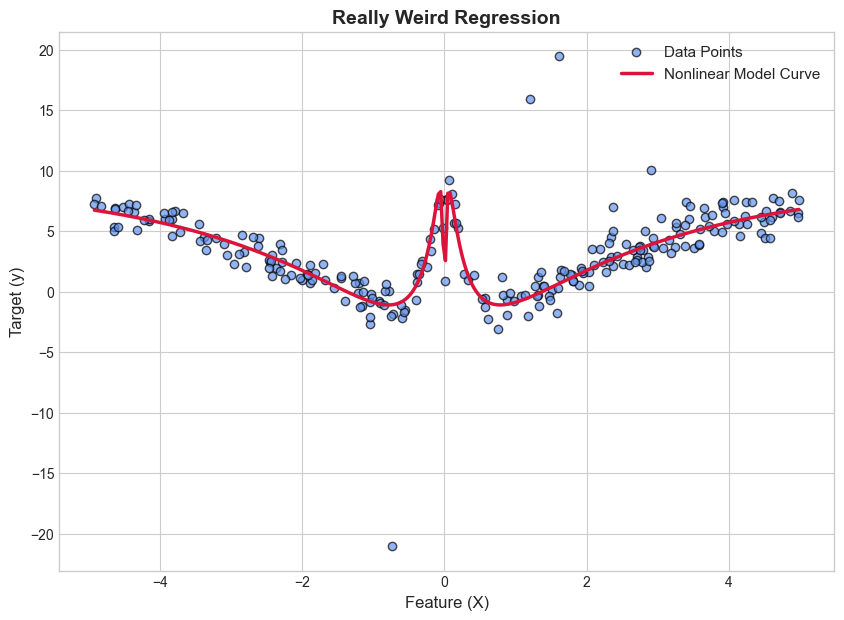

In [306]:
X_add, y_add, coefs = generate_regression_data(
    n_samples=250, 
    n_features=1, 
    mode='additional', 
    noise=1.0, 
    n_outliers=5, 
    random_seed=STUDENT_NO, 
    return_coef=True
)
evaluate_regression_model(X_add, y_add, nonlinear_params=coefs, print_results=True)
plot_regression_model(X_add, y_add, 
                      nonlinear_params=coefs,
                      title='Really Weird Regression')

## 1.2. Tuning Linear Regression on non-linear data

Just change coefficients of the Linear model and observe changes in loss function

In [307]:
# Generating data
X_nonlin, y_nonlin, coefs = generate_regression_data(
    n_samples=300, 
    n_features=1, 
    mode='nonlinear', 
    noise=5.0,
    n_outliers=10, 
    random_seed=STUDENT_NO, 
    return_coef=True
)

----- 📈 Model Evaluation -----
MAE       291.2054
MSE    107510.7086
RMSE      327.8883
R2     -13894.4139
-----------------------------


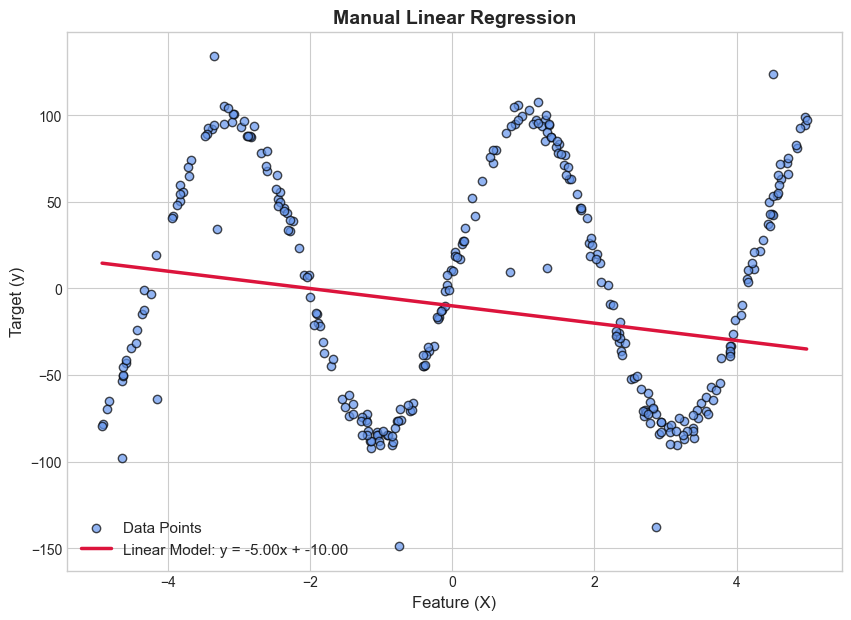

In [308]:
lin_model_weights = [-5, -10]
evaluate_regression_model(X_nonlin, y_nonlin, model=lin_model_weights, print_results=True)
plot_regression_model(X_nonlin, y_nonlin, 
                      weights=[lin_model_weights[0], ], 
                      intercept=lin_model_weights[1],
                      title='Manual Linear Regression')

----- 📈 Model Evaluation -----
MAE     2.4205
MSE     7.8962
RMSE    2.8100
R2     -0.0206
-----------------------------


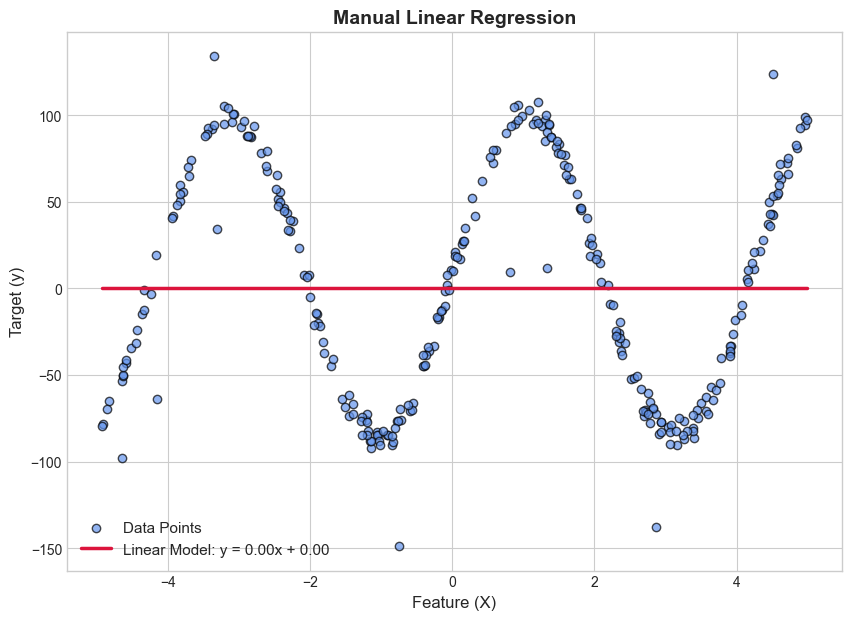

In [309]:
lin_model_weights = [0, 0]
evaluate_regression_model(X_nonlin, y_nonlin, model=lin_model_weights, print_results=True)
plot_regression_model(X_nonlin, y_nonlin, 
                      weights=[lin_model_weights[0], ], 
                      intercept=lin_model_weights[1],
                      title='Manual Linear Regression')

### У функції `evaluate_regression_model` та `plot_regression_model` була додана підтримка функції $y = a*20*\sin(X) + b$ 

----- 📈 Model Evaluation -----
MAE      122.4585
MSE    18841.1897
RMSE     137.2632
R2     -2434.1633
-----------------------------


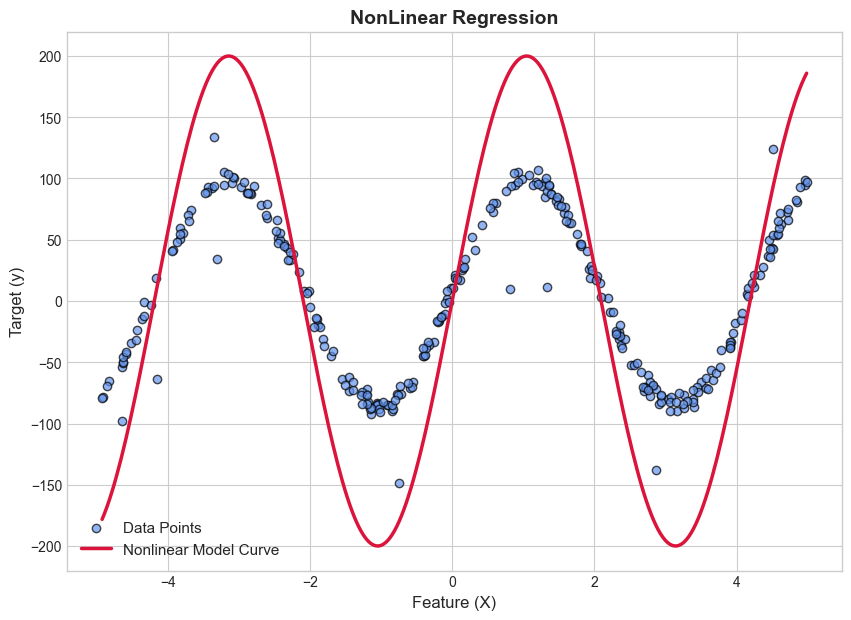

In [310]:
nonlin_model_weights = [10, 0]
evaluate_regression_model(X_nonlin, y_nonlin, nonlinear_params=nonlin_model_weights, print_results=True)
plot_regression_model(X_nonlin, y_nonlin,
                      nonlinear_params=nonlin_model_weights,
                      title='NonLinear Regression')

----- 📈 Model Evaluation -----
MAE      61.3544
MSE    4736.6639
RMSE     68.8234
R2     -611.1986
-----------------------------


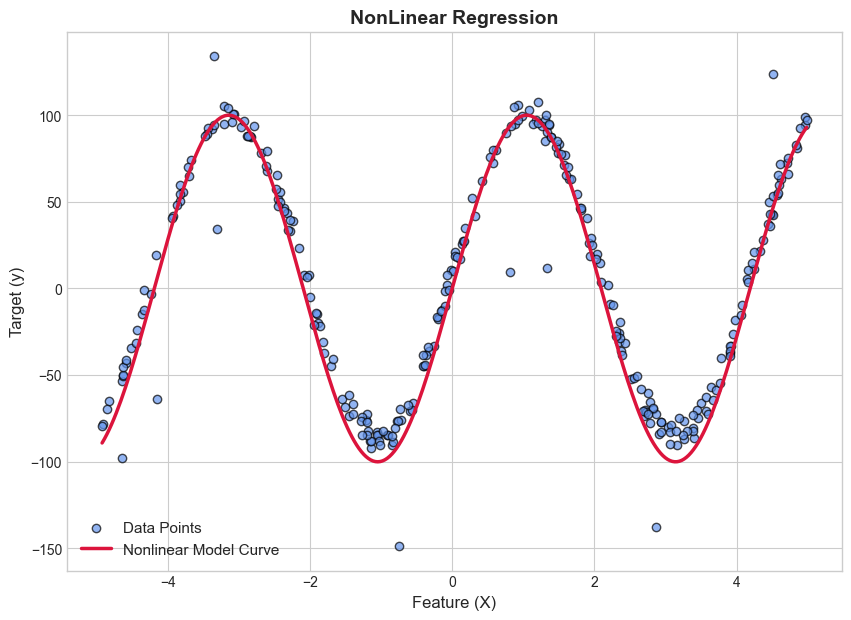

In [311]:
nonlin_model_weights = [5, 0]
evaluate_regression_model(X_nonlin, y_nonlin, nonlinear_params=nonlin_model_weights, print_results=True)
plot_regression_model(X_nonlin, y_nonlin,
                      nonlinear_params=nonlin_model_weights,
                      title='NonLinear Regression')

----- 📈 Model Evaluation -----
MAE      55.9129
MSE    3982.0695
RMSE     63.1036
R2     -513.6697
-----------------------------


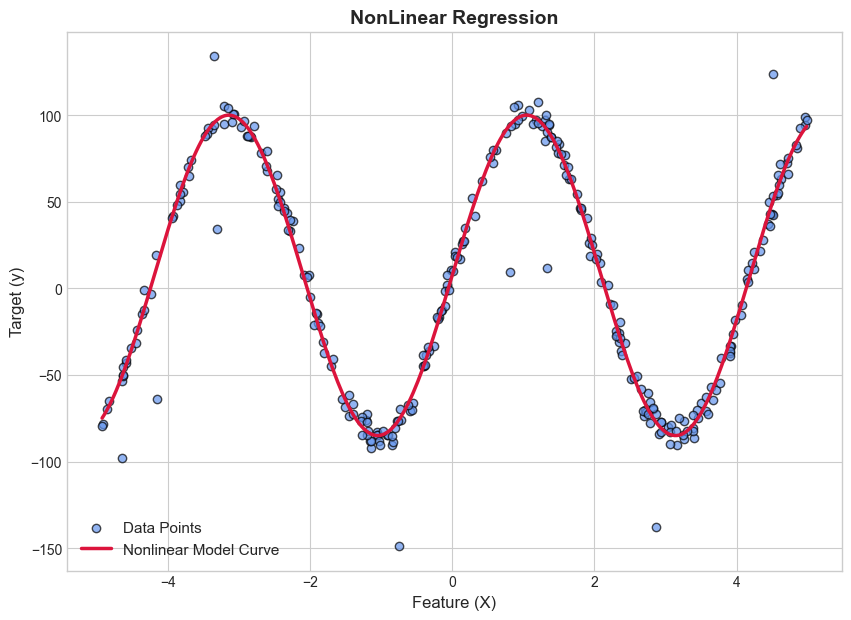

In [312]:
evaluate_regression_model(X_nonlin, y_nonlin, nonlinear_params=coefs, print_results=True)
plot_regression_model(X_nonlin, y_nonlin,
                      nonlinear_params=coefs,
                      title='NonLinear Regression')

## 1.3. Configuring various linear models from sklearn library

Try to configure hyperparameters of various linear regression models from sklearn.

`WATCHME` Videos to better understand how it works:

* [Linear Regression](https://www.youtube.com/watch?v=3dhcmeOTZ_Q)
* [Least Squares Method for training Linear Regression model](https://www.youtube.com/watch?v=P8hT5nDai6A)
* [Can your Regression Model Handle Outliers? | HuberRegressor](https://www.youtube.com/watch?v=C6Z8Ps23Omw)
* [Robust Regression with the L1 Norm](https://www.youtube.com/watch?v=KF5LaUVTBOY)
* [Poisson Regression](https://www.youtube.com/watch?v=Obpz_Uvo2rQ)


In [313]:
from sklearn.linear_model import LinearRegression, HuberRegressor, PoissonRegressor, LogisticRegression

### 1.3.1. Playing with `HuberRegressor`

In [314]:
hub_model = HuberRegressor(
    epsilon = 1.35,
    max_iter = 100,
    alpha = 0.0001,
    warm_start = False,
    fit_intercept = True,
    tol = 1e-05,
)

----- 📈 Model Evaluation -----
MAE      5.1043
MSE    107.9840
RMSE    10.3915
R2       0.3117
-----------------------------


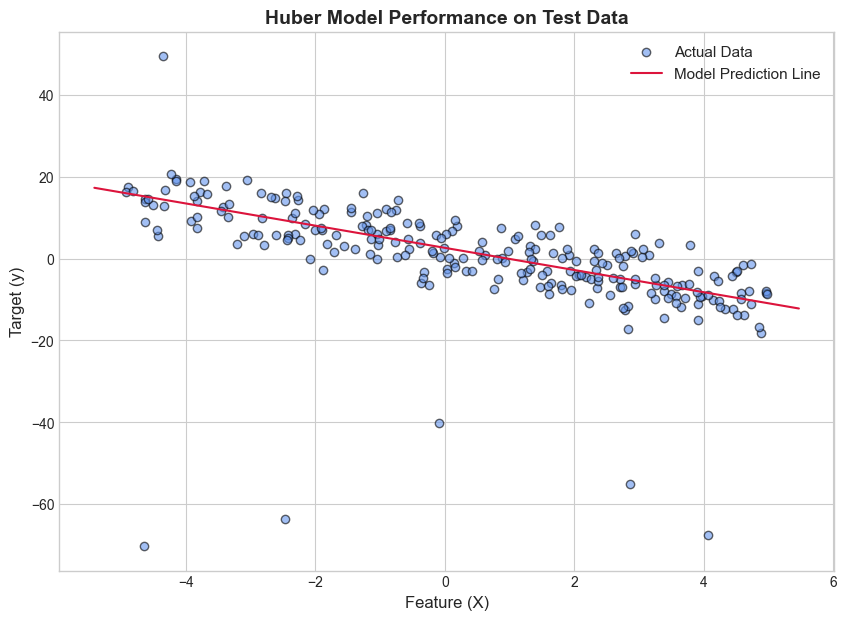

In [315]:
hub_model.fit(X_lin, y_lin)

evaluate_regression_model(y_lin, X_lin, model=hub_model, print_results=True)
plot_sklearn_regression(hub_model, X_lin.reshape(-1, 1), y_lin, title="Huber Model Performance on Test Data")

----- 📈 Model Evaluation -----
MAE      7.4337
MSE    139.4519
RMSE    11.8090
R2       0.1111
-----------------------------


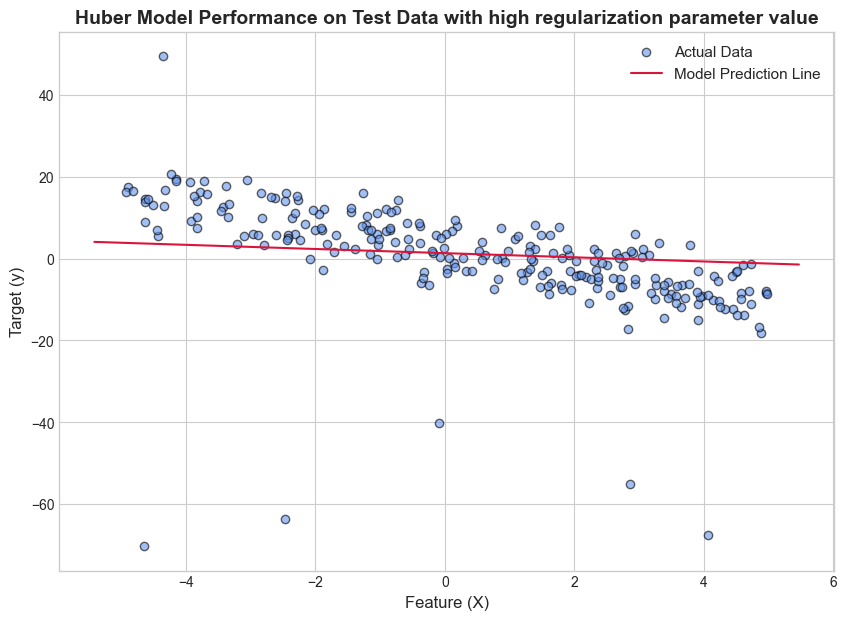

In [316]:
hub_model = HuberRegressor(
    epsilon = 1.35,
    max_iter = 100,
    alpha = 1000,
    warm_start = False,
    fit_intercept = True,
    tol = 1e-05,
)
hub_model.fit(X_lin, y_lin)

evaluate_regression_model(y_lin, X_lin, model=hub_model, print_results=True)
plot_sklearn_regression(hub_model, X_lin.reshape(-1, 1), y_lin, title="Huber Model Performance on Test Data with high regularization parameter value")

----- 📈 Model Evaluation -----
MAE      5.1598
MSE    106.9528
RMSE    10.3418
R2       0.3183
-----------------------------


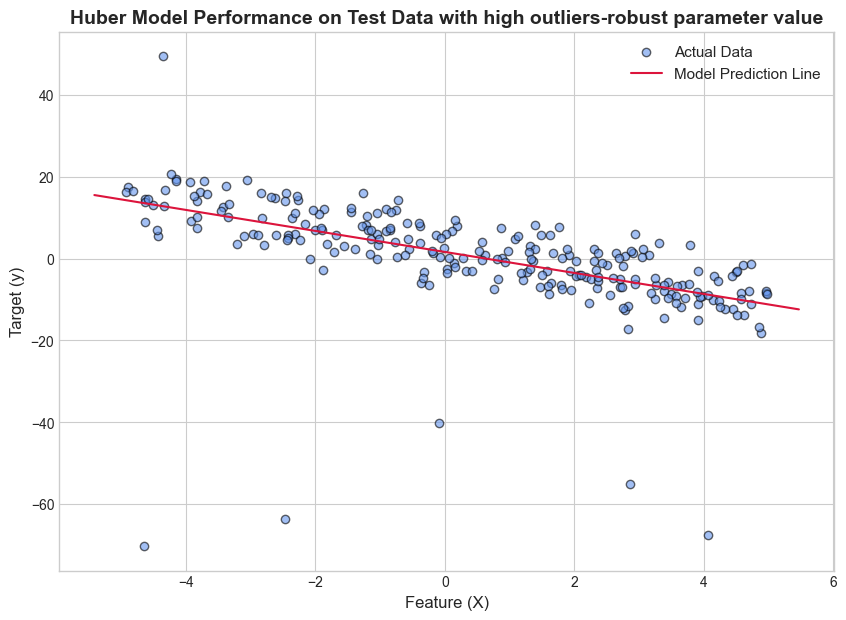

In [317]:
hub_model = HuberRegressor(
    epsilon = 10000,
    max_iter = 100,
    alpha = 0.0001,
    warm_start = False,
    fit_intercept = True,
    tol = 1e-05,
)
hub_model.fit(X_lin, y_lin)

evaluate_regression_model(y_lin, X_lin, model=hub_model, print_results=True)
plot_sklearn_regression(hub_model, X_lin.reshape(-1, 1), y_lin, title="Huber Model Performance on Test Data with high outliers-robust parameter value")

#### Ефект не помітний через малу кількість викидів, але помилка трохи зросла

----- 📈 Model Evaluation -----
MAE      6.7927
MSE    126.5695
RMSE    11.2503
R2       0.1932
-----------------------------


C:\Users\rodio\PycharmProjects\DataMining\.venv\Lib\site-packages\sklearn\linear_model\_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


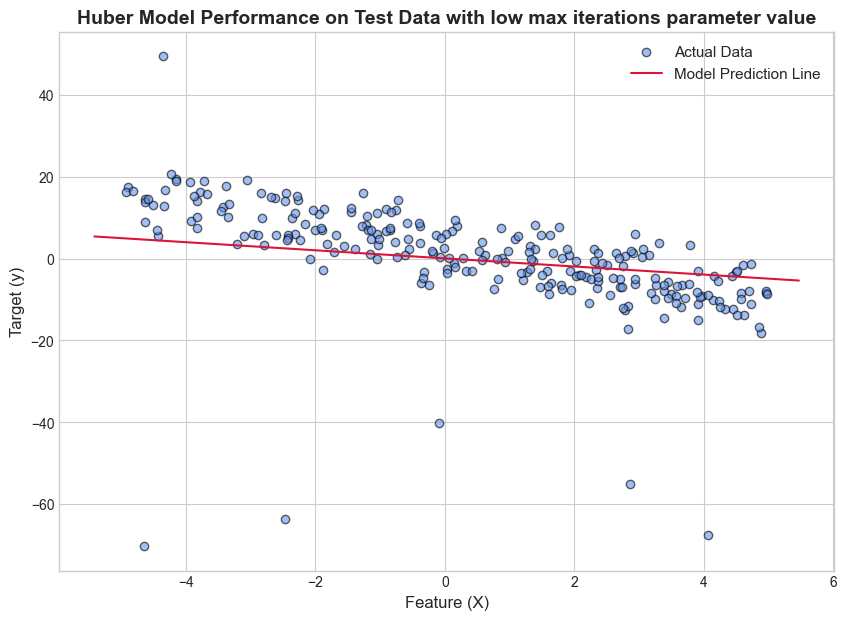

In [318]:
hub_model = HuberRegressor(
    epsilon = 1.35,
    max_iter = 1,
    alpha = 0.0001,
    warm_start = False,
    fit_intercept = True,
    tol = 1e-05,
)
hub_model.fit(X_lin, y_lin)

evaluate_regression_model(y_lin, X_lin, model=hub_model, print_results=True)
plot_sklearn_regression(hub_model, X_lin.reshape(-1, 1), y_lin, title="Huber Model Performance on Test Data with low max iterations parameter value")

##### Через мінімальну кількість ітерацій градієнт не підійшов й близько до мінімуму, `ConvergeWarning` виникає через те що за цю кількість ітерацій алгоритм не дійшов до заданої точності у 1e-05

### 1.3.2. Playing with `PoissonRegressor`

In [319]:
pois_model = PoissonRegressor(
    alpha = 1.0,
    fit_intercept = True,
    solver = "lbfgs",
    max_iter = 100,
    tol= 1e-4,
    warm_start = True,
    verbose = 0
)

----- 📈 Model Evaluation -----
MAE      5.1614
MSE    107.3819
RMSE    10.3625
R2       0.3155
-----------------------------


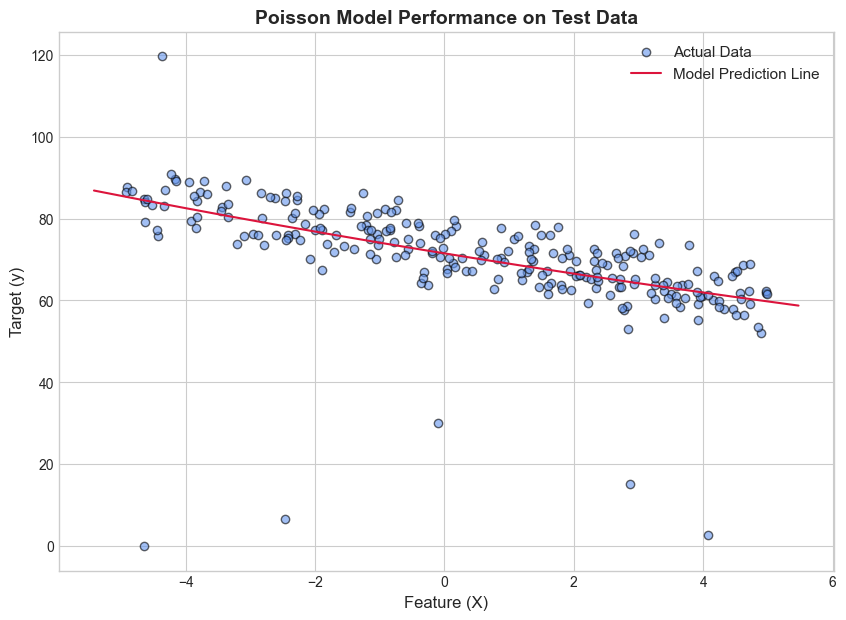

In [320]:
pois_model.fit(X_lin, y_lin - np.min(y_lin))

evaluate_regression_model(y_lin - np.min(y_lin), X_lin, model=pois_model, print_results=True)
plot_sklearn_regression(pois_model, X_lin.reshape(-1, 1), y_lin - np.min(y_lin), title="Poisson Model Performance on Test Data")

----- 📈 Model Evaluation -----
MAE      6.8015
MSE    128.0923
RMSE    11.3178
R2       0.1835
-----------------------------


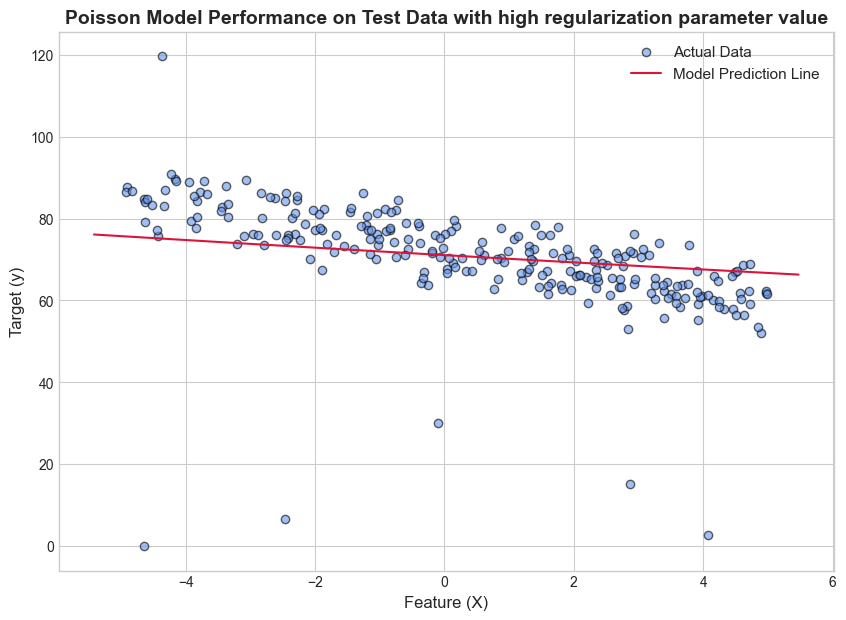

In [321]:
pois_model = PoissonRegressor(
    alpha = 1000,
    fit_intercept = True,
    solver = "lbfgs",
    max_iter = 100,
    tol= 1e-4,
    warm_start = True,
    verbose = 0
)

pois_model.fit(X_lin, y_lin - np.min(y_lin))

evaluate_regression_model(y_lin - np.min(y_lin), X_lin, model=pois_model, print_results=True)
plot_sklearn_regression(pois_model, X_lin.reshape(-1, 1), y_lin - np.min(y_lin), title="Poisson Model Performance on Test Data with high regularization parameter value")

----- 📈 Model Evaluation -----
MAE      5.1614
MSE    107.3819
RMSE    10.3625
R2       0.3155
-----------------------------


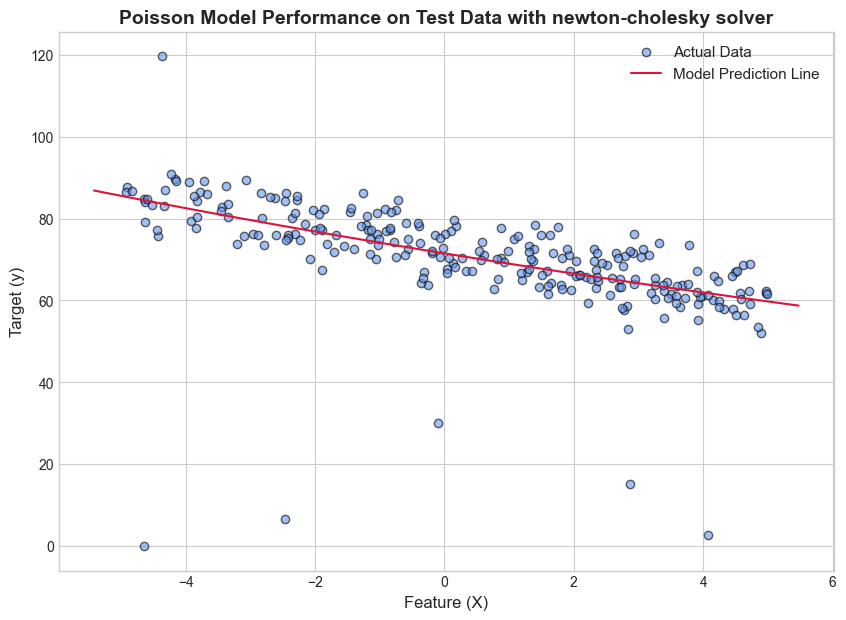

In [322]:
pois_model = PoissonRegressor(
    alpha = 1.0,
    fit_intercept = True,
    solver = "newton-cholesky",
    max_iter = 100,
    tol= 1e-4,
    warm_start = True,
    verbose = 0
)

pois_model.fit(X_lin, y_lin - np.min(y_lin))

evaluate_regression_model(y_lin - np.min(y_lin), X_lin, model=pois_model, print_results=True)
plot_sklearn_regression(pois_model, X_lin.reshape(-1, 1), y_lin - np.min(y_lin), title="Poisson Model Performance on Test Data with newton-cholesky solver")

----- 📈 Model Evaluation -----
MAE      8.3850
MSE    156.8819
RMSE    12.5252
R2       0.0000
-----------------------------


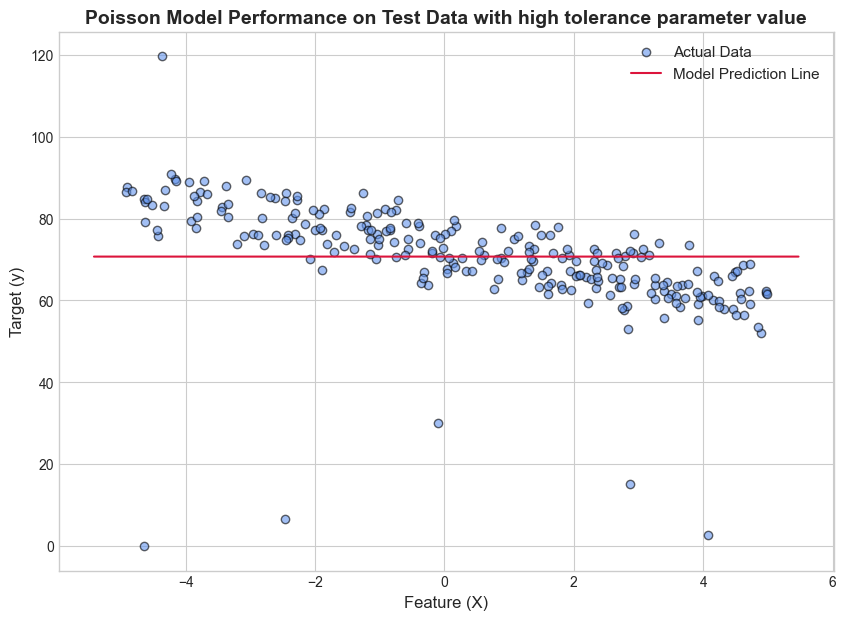

In [323]:
pois_model = PoissonRegressor(
    alpha = 1.0,
    fit_intercept = True,
    solver = "lbfgs",
    max_iter = 100,
    tol= 100,
    warm_start = True,
    verbose = 0
)

pois_model.fit(X_lin, y_lin - np.min(y_lin))

evaluate_regression_model(y_lin - np.min(y_lin), X_lin, model=pois_model, print_results=True)
plot_sklearn_regression(pois_model, X_lin.reshape(-1, 1), y_lin - np.min(y_lin), title="Poisson Model Performance on Test Data with high tolerance parameter value")

----- 📈 Model Evaluation -----
MAE      67.3325
MSE    4752.7486
RMSE     68.9402
R2      -29.2951
-----------------------------


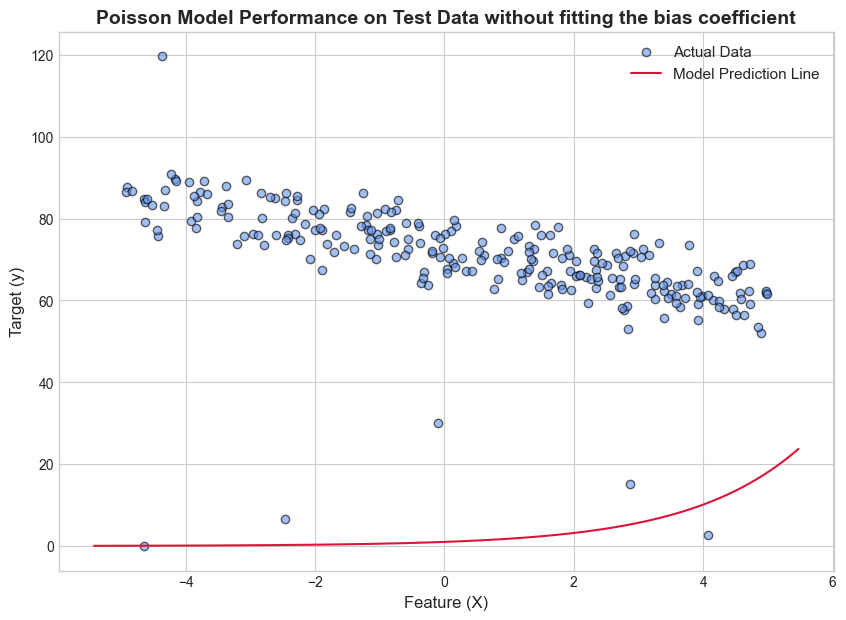

In [324]:
pois_model = PoissonRegressor(
    alpha = 1.0,
    fit_intercept = False,
    solver = "lbfgs",
    max_iter = 100,
    tol= 1e-4,
    warm_start = True,
    verbose = 0
)

pois_model.fit(X_lin, y_lin - np.min(y_lin))

evaluate_regression_model(y_lin - np.min(y_lin), X_lin, model=pois_model, print_results=True)
plot_sklearn_regression(pois_model, X_lin.reshape(-1, 1), y_lin - np.min(y_lin), title="Poisson Model Performance on Test Data without fitting the bias coefficient")

## 1.4. Configure non-linear models from sklearn library

`WATCHME` Videos to better understand how it works:

* [StatQuest: K-nearest neighbors, Clearly Explained](https://www.youtube.com/watch?v=HVXime0nQeI)
* [K-Nearest Neighbors Regression](https://www.youtube.com/watch?v=BvQVovMefsM)
* [Decision and Classification Trees, Clearly Explained](https://www.youtube.com/watch?v=_L39rN6gz7Y)
* [Support Vector Machines Part 1 (of 3): Main Ideas](https://www.youtube.com/watch?v=efR1C6CvhmE) other 3 videos in the description


In [325]:
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.svm import SVR

### 1.4.1. Playing with `KNeighborsRegressor`

----- 📈 Model Evaluation -----
MAE     5.3871
MSE    89.6409
RMSE    9.4679
R2      0.4286
-----------------------------


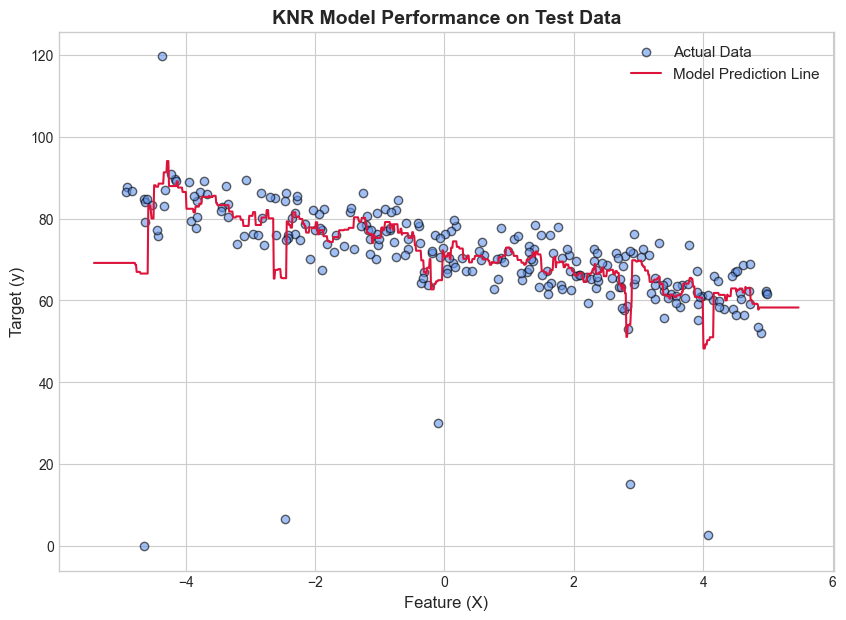

In [326]:
knr_model = KNeighborsRegressor(
    n_neighbors = 5,
    weights = 'uniform',
    algorithm = 'auto',
    leaf_size = 30,
    p = 2,
    metric = 'minkowski',
    metric_params = None,
    n_jobs = None
)

knr_model.fit(X_lin, y_lin - np.min(y_lin))

evaluate_regression_model(y_lin - np.min(y_lin), X_lin, model=knr_model, print_results=True)
plot_sklearn_regression(knr_model, X_lin.reshape(-1, 1), y_lin - np.min(y_lin), title="KNR Model Performance on Test Data")

----- 📈 Model Evaluation -----
MAE    0.0000
MSE    0.0000
RMSE   0.0000
R2     1.0000
-----------------------------


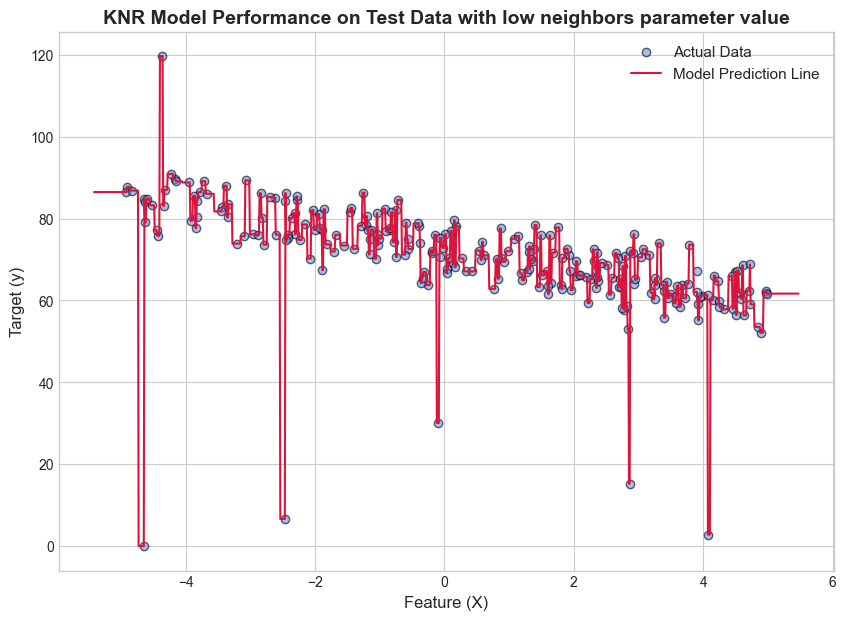

In [327]:
knr_model = KNeighborsRegressor(
    n_neighbors = 1,
    weights = 'uniform',
    algorithm = 'auto',
    leaf_size = 30,
    p = 2,
    metric = 'minkowski',
    metric_params = None,
    n_jobs = None
)

knr_model.fit(X_lin, y_lin - np.min(y_lin))

evaluate_regression_model(y_lin - np.min(y_lin), X_lin, model=knr_model, print_results=True)
plot_sklearn_regression(knr_model, X_lin.reshape(-1, 1), y_lin - np.min(y_lin), title="KNR Model Performance on Test Data with low neighbors parameter value")

----- 📈 Model Evaluation -----
MAE      5.5271
MSE    109.9483
RMSE    10.4856
R2       0.2992
-----------------------------


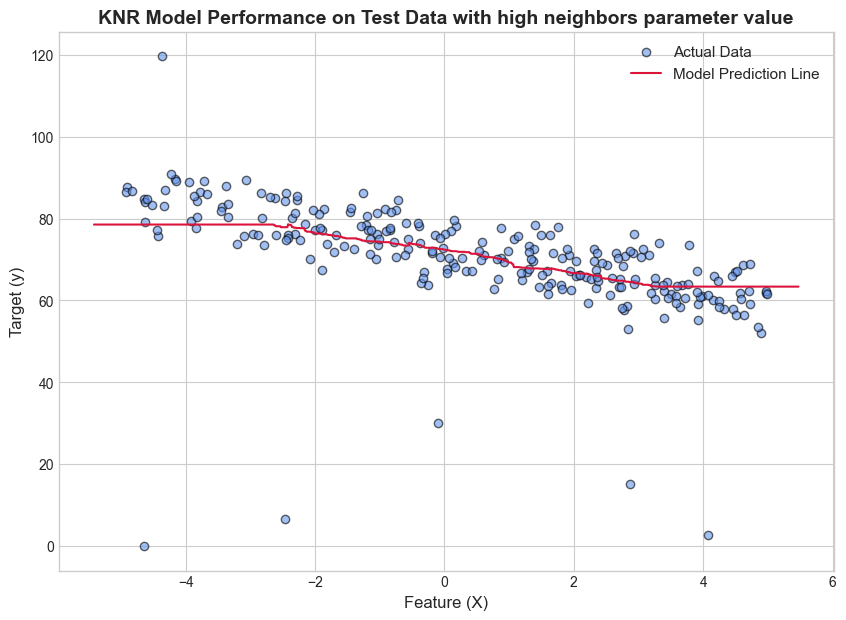

In [328]:
knr_model = KNeighborsRegressor(
    n_neighbors = 100,
    weights = 'uniform',
    algorithm = 'auto',
    leaf_size = 30,
    p = 2,
    metric = 'minkowski',
    metric_params = None,
    n_jobs = None
)

knr_model.fit(X_lin, y_lin - np.min(y_lin))

evaluate_regression_model(y_lin - np.min(y_lin), X_lin, model=knr_model, print_results=True)
plot_sklearn_regression(knr_model, X_lin.reshape(-1, 1), y_lin - np.min(y_lin), title="KNR Model Performance on Test Data with high neighbors parameter value")

----- 📈 Model Evaluation -----
MAE    0.0000
MSE    0.0000
RMSE   0.0000
R2     1.0000
-----------------------------


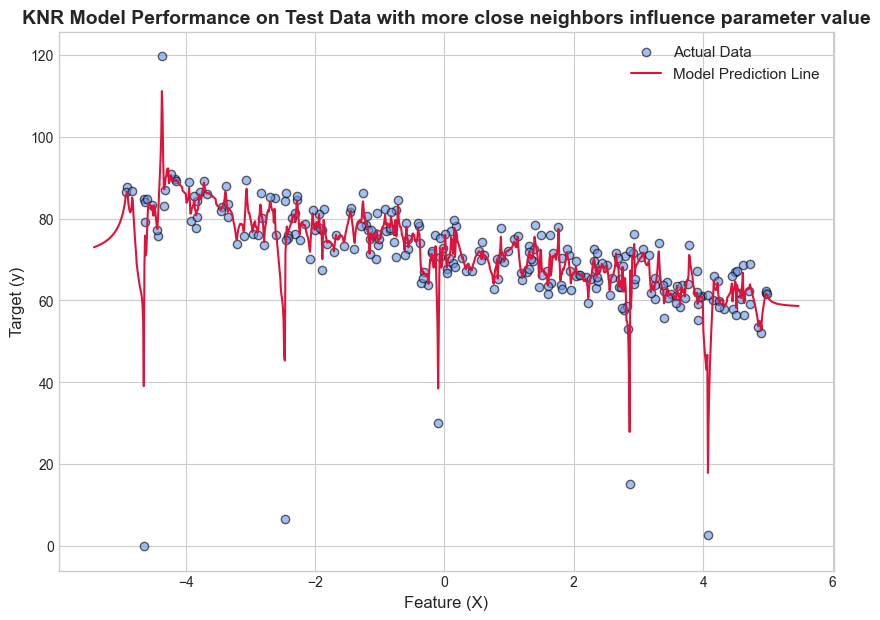

In [329]:
knr_model = KNeighborsRegressor(
    n_neighbors = 5,
    weights = 'distance',
    algorithm = 'auto',
    leaf_size = 30,
    p = 2,
    metric = 'minkowski',
    metric_params = None,
    n_jobs = None
)

knr_model.fit(X_lin, y_lin - np.min(y_lin))

evaluate_regression_model(y_lin - np.min(y_lin), X_lin, model=knr_model, print_results=True)
plot_sklearn_regression(knr_model, X_lin.reshape(-1, 1), y_lin - np.min(y_lin), title="KNR Model Performance on Test Data with more close neighbors influence parameter value")

### 1.4.2. Playing with `RadiusNeighborsRegressor`

----- 📈 Model Evaluation -----
MAE      5.1725
MSE    105.8312
RMSE    10.2874
R2       0.3254
-----------------------------


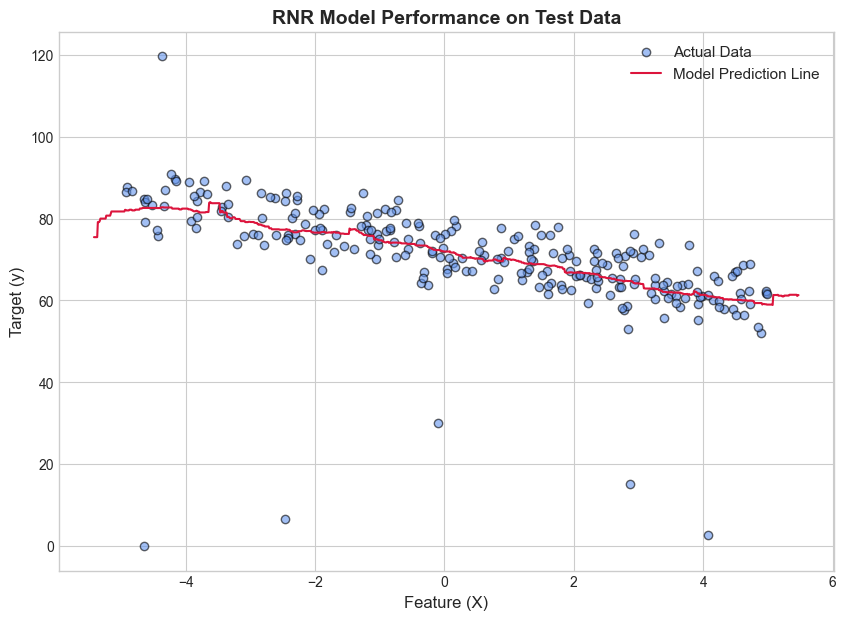

In [330]:
rnr_model = RadiusNeighborsRegressor(
    radius = 1.0,
    weights = "uniform",
    algorithm = "auto",
    leaf_size = 30,
    p = 2,
    metric = 'minkowski',
    metric_params = None,
    n_jobs = None
)

rnr_model.fit(X_lin, y_lin - np.min(y_lin))

evaluate_regression_model(y_lin - np.min(y_lin), X_lin, model=rnr_model, print_results=True)
plot_sklearn_regression(rnr_model, X_lin.reshape(-1, 1), y_lin - np.min(y_lin), title="RNR Model Performance on Test Data")

----- 📈 Model Evaluation -----
MAE     5.1189
MSE    86.9157
RMSE    9.3229
R2      0.4460
-----------------------------


C:\Users\rodio\PycharmProjects\DataMining\.venv\Lib\site-packages\sklearn\neighbors\_regression.py:513: UserWarning: One or more samples have no neighbors within specified radius; predicting NaN.
  warnings.warn(empty_warning_msg)


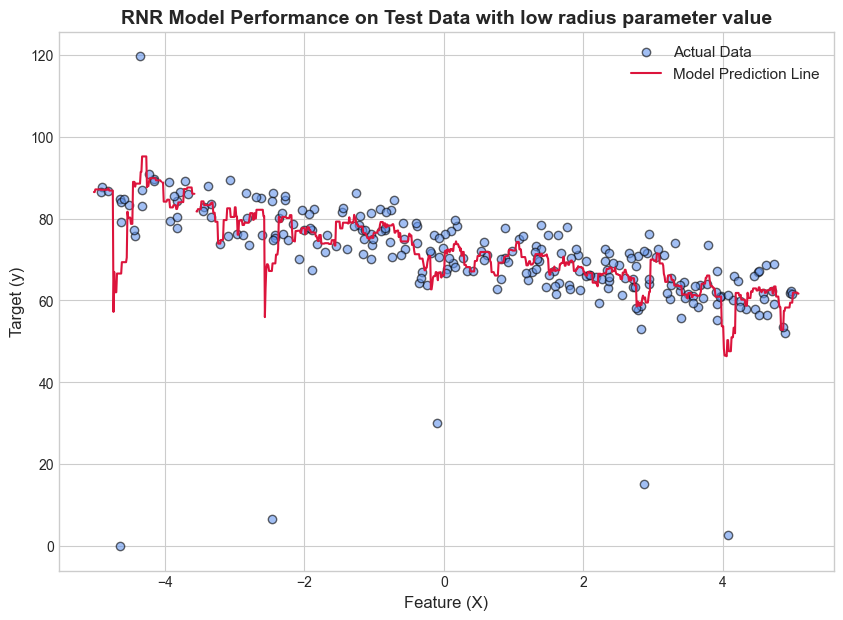

In [331]:
rnr_model = RadiusNeighborsRegressor(
    radius = 0.1,
    weights = "uniform",
    algorithm = "auto",
    leaf_size = 30,
    p = 2,
    metric = 'minkowski',
    metric_params = None,
    n_jobs = None
)

rnr_model.fit(X_lin, y_lin - np.min(y_lin))

evaluate_regression_model(y_lin - np.min(y_lin), X_lin, model=rnr_model, print_results=True)
plot_sklearn_regression(rnr_model, X_lin.reshape(-1, 1), y_lin - np.min(y_lin), title="RNR Model Performance on Test Data with low radius parameter value")

### 1.4.3. Playing with `DecisionTreeRegressor`

----- 📈 Model Evaluation -----
MAE    0.0000
MSE    0.0000
RMSE   0.0000
R2     1.0000
-----------------------------


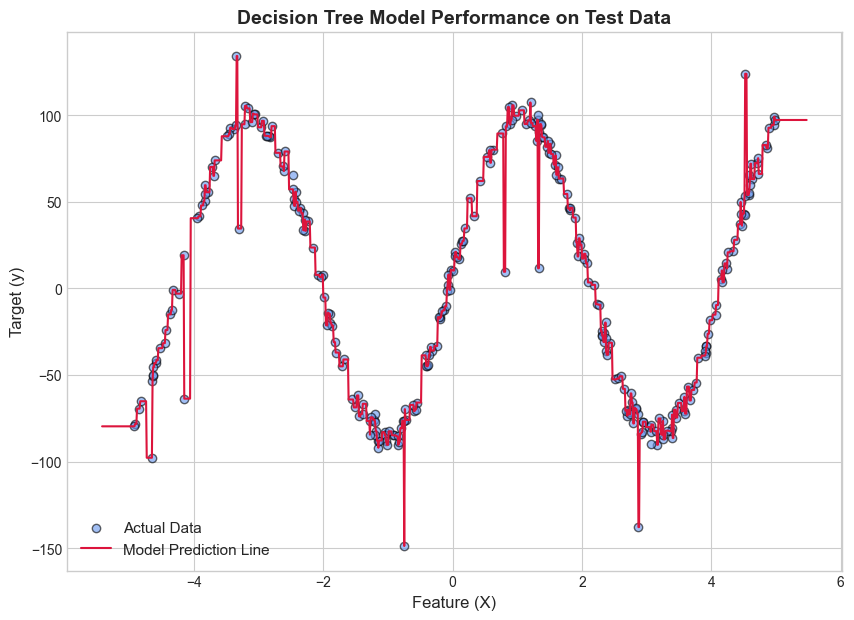

In [332]:
dt_model = DecisionTreeRegressor(
     criterion = "squared_error",
     splitter = "best",
     max_depth = None,
     min_samples_split = 2,
     min_samples_leaf = 1,
     min_weight_fraction_leaf = 0.0,
     max_features = None,
     random_state = None,
     max_leaf_nodes = None,
     min_impurity_decrease = 0.0,
     ccp_alpha = 0.0,
     monotonic_cst = None
)
dt_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=dt_model, print_results=True)
plot_sklearn_regression(dt_model, X_nonlin, y_nonlin, title="Decision Tree Model Performance on Test Data")

----- 📈 Model Evaluation -----
MAE      54.0659
MSE    3926.4223
RMSE     62.6612
R2        0.0846
-----------------------------


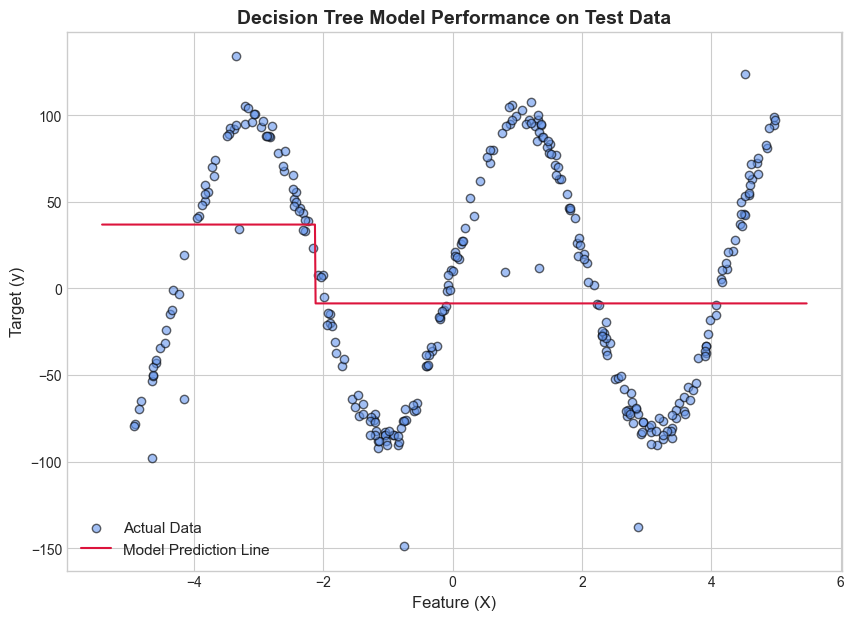

In [333]:
dt_model = DecisionTreeRegressor(
     criterion = "squared_error",
     splitter = "best",
     max_depth = 1,
     min_samples_split = 2,
     min_samples_leaf = 1,
     min_weight_fraction_leaf = 0.0,
     max_features = None,
     random_state = None,
     max_leaf_nodes = None,
     min_impurity_decrease = 0.0,
     ccp_alpha = 0.0,
     monotonic_cst = None
)
dt_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=dt_model, print_results=True)
plot_sklearn_regression(dt_model, X_nonlin, y_nonlin, title="Decision Tree Model Performance on Test Data")

----- 📈 Model Evaluation -----
MAE      31.2410
MSE    1656.6437
RMSE     40.7019
R2        0.6138
-----------------------------


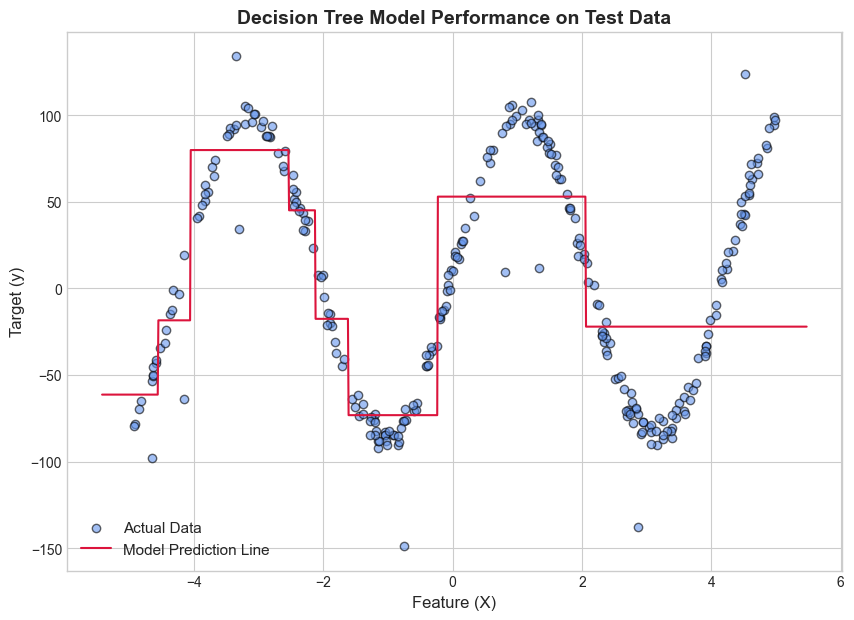

In [334]:
dt_model = DecisionTreeRegressor(
     criterion = "squared_error",
     splitter = "best",
     max_depth = 3,
     min_samples_split = 2,
     min_samples_leaf = 1,
     min_weight_fraction_leaf = 0.0,
     max_features = None,
     random_state = None,
     max_leaf_nodes = None,
     min_impurity_decrease = 0.0,
     ccp_alpha = 0.0,
     monotonic_cst = None
)
dt_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=dt_model, print_results=True)
plot_sklearn_regression(dt_model, X_nonlin, y_nonlin, title="Decision Tree Model Performance on Test Data")

----- 📈 Model Evaluation -----
MAE     16.7425
MSE    502.0801
RMSE    22.4071
R2       0.8829
-----------------------------


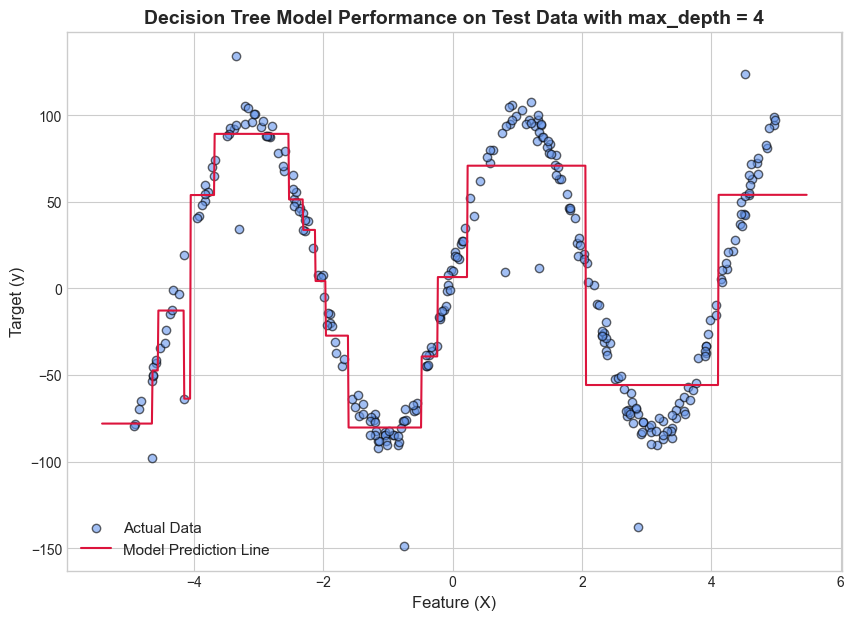

In [335]:
dt_model = DecisionTreeRegressor(
     criterion = "squared_error",
     splitter = "best",
     max_depth = 4,
     min_samples_split = 2,
     min_samples_leaf = 1,
     min_weight_fraction_leaf = 0.0,
     max_features = None,
     random_state = None,
     max_leaf_nodes = None,
     min_impurity_decrease = 0.0,
     ccp_alpha = 0.0,
     monotonic_cst = None
)
dt_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=dt_model, print_results=True)
plot_sklearn_regression(dt_model, X_nonlin, y_nonlin, title="Decision Tree Model Performance on Test Data with max_depth = 4")

----- 📈 Model Evaluation -----
MAE      9.6663
MSE    195.4029
RMSE    13.9787
R2       0.9544
-----------------------------


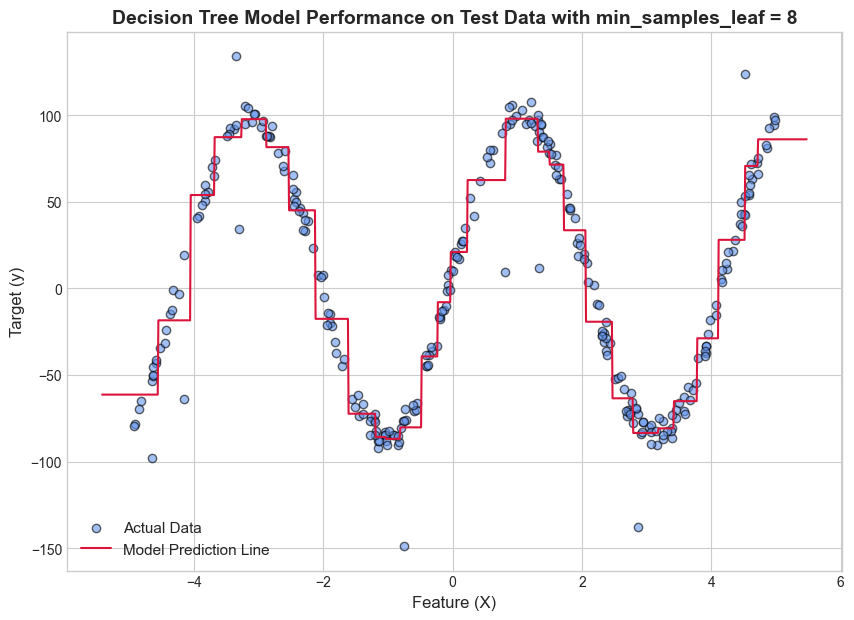

In [336]:
dt_model = DecisionTreeRegressor(
     criterion = "squared_error",
     splitter = "best",
     max_depth = None,
     min_samples_split = 2,
     min_samples_leaf = 8,
     min_weight_fraction_leaf = 0.0,
     max_features = None,
     random_state = None,
     max_leaf_nodes = None,
     min_impurity_decrease = 0.0,
     ccp_alpha = 0.0,
     monotonic_cst = None
)
dt_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=dt_model, print_results=True)
plot_sklearn_regression(dt_model, X_nonlin, y_nonlin, title="Decision Tree Model Performance on Test Data with min_samples_leaf = 8")

----- 📈 Model Evaluation -----
MAE      5.3679
MSE    101.6289
RMSE    10.0811
R2       0.9763
-----------------------------


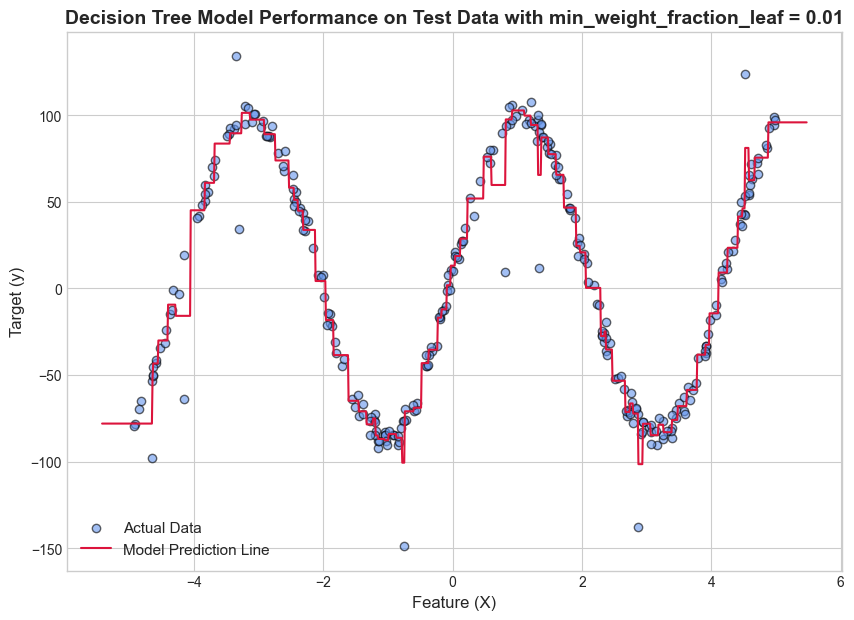

In [337]:
dt_model = DecisionTreeRegressor(
     criterion = "squared_error",
     splitter = "best",
     max_depth = None,
     min_samples_split = 2,
     min_samples_leaf = 1,
     min_weight_fraction_leaf = 0.01,
     max_features = None,
     random_state = None,
     max_leaf_nodes = None,
     min_impurity_decrease = 0.0,
     ccp_alpha = 0.0,
     monotonic_cst = None
)
dt_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=dt_model, print_results=True)
plot_sklearn_regression(dt_model, X_nonlin, y_nonlin, title="Decision Tree Model Performance on Test Data with min_weight_fraction_leaf = 0.01")

### 1.4.4. Playing with `AdaBoostRegressor`

----- 📈 Model Evaluation -----
MAE     16.9421
MSE    438.9123
RMSE    20.9502
R2       0.8977
-----------------------------


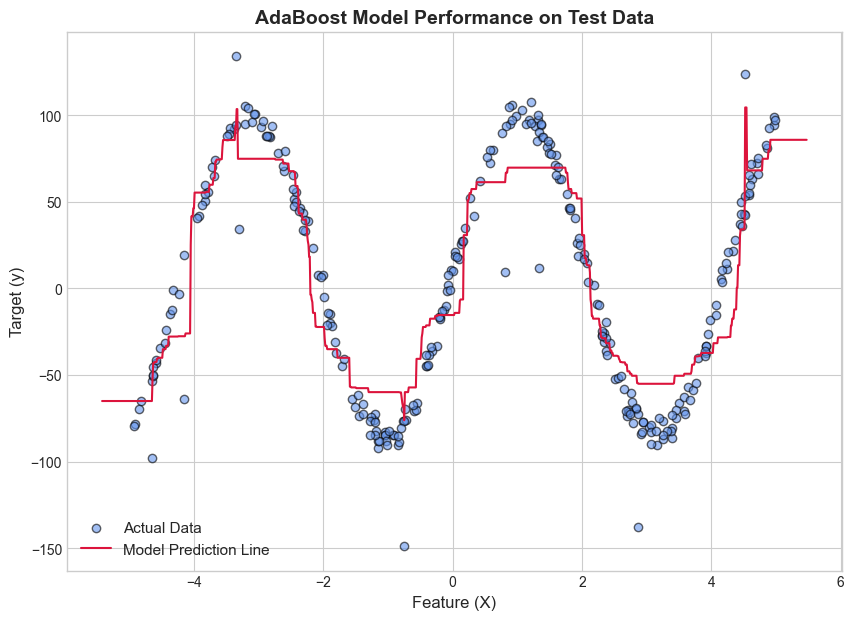

In [338]:
abr_model = AdaBoostRegressor(
    estimator = None,
    n_estimators = 50,
    learning_rate = 1.0,
    loss = "linear",
    random_state = STUDENT_NO,
)
abr_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=abr_model, print_results=True)
plot_sklearn_regression(abr_model, X_nonlin, y_nonlin, title="AdaBoost Model Performance on Test Data")

----- 📈 Model Evaluation -----
MAE      58.2741
MSE    4289.2138
RMSE     65.4921
R2        0.0000
-----------------------------


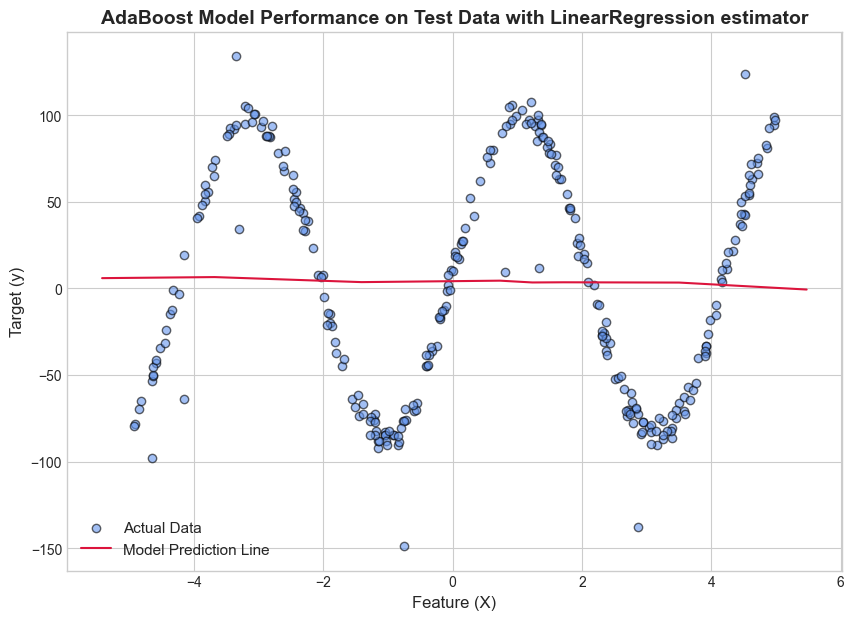

In [339]:
abr_model = AdaBoostRegressor(
    estimator = LinearRegression(),
    n_estimators = 50,
    learning_rate = 1.0,
    loss = "linear",
    random_state = STUDENT_NO,
)
abr_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=abr_model, print_results=True)
plot_sklearn_regression(abr_model, X_nonlin, y_nonlin, title="AdaBoost Model Performance on Test Data with LinearRegression estimator")

### 1.4.5. Playing with `RandomForestRegressor`

----- 📈 Model Evaluation -----
MAE     3.0300
MSE    33.6761
RMSE    5.8031
R2      0.9921
-----------------------------


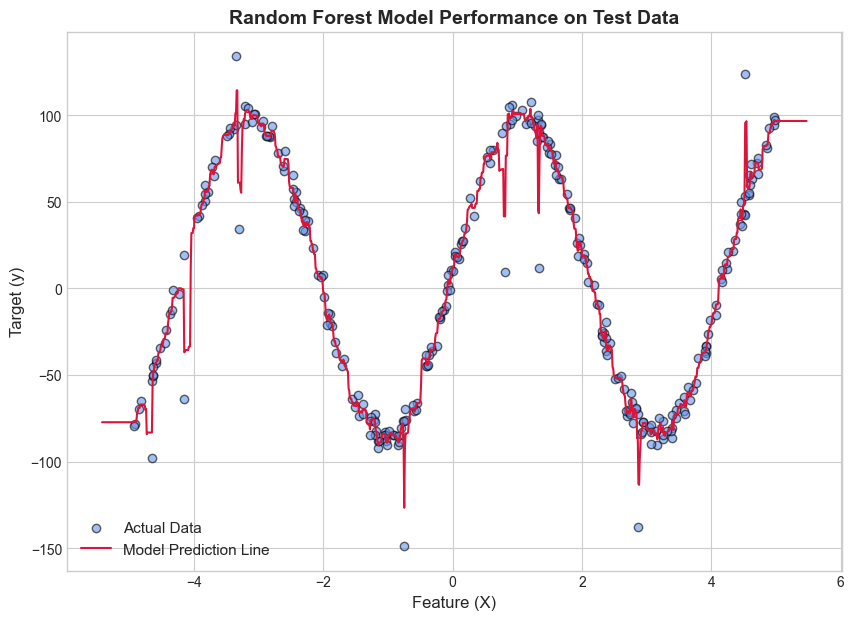

In [340]:
rf_model = RandomForestRegressor(
    n_estimators = 100,
    criterion = "squared_error",
    max_depth = None,
    min_samples_split = 2,
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0,
    max_features = 1.0,
    max_leaf_nodes = None,
    min_impurity_decrease = 0.0,
    bootstrap = True,
    oob_score = False,
    n_jobs = None,
    random_state = None,
    verbose = 0,
    warm_start = False,
    ccp_alpha = 0.0,
    max_samples = None,
    monotonic_cst = None
)
rf_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=rf_model, print_results=True)
plot_sklearn_regression(rf_model, X_nonlin, y_nonlin, title="Random Forest Model Performance on Test Data")

----- 📈 Model Evaluation -----
MAE      6.7267
MSE    101.2620
RMSE    10.0629
R2       0.9764
-----------------------------


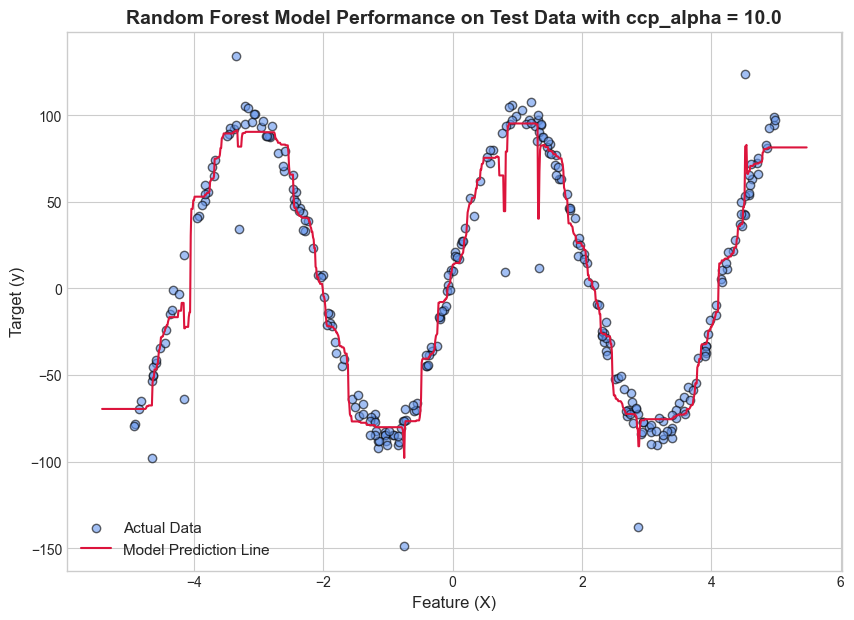

In [341]:
rf_model = RandomForestRegressor(
    n_estimators = 100,
    criterion = "squared_error",
    max_depth = None,
    min_samples_split = 2,
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0,
    max_features = 1.0,
    max_leaf_nodes = None,
    min_impurity_decrease = 0.0,
    bootstrap = True,
    oob_score = False,
    n_jobs = None,
    random_state = None,
    verbose = 0,
    warm_start = False,
    ccp_alpha = 10.0,
    max_samples = None,
    monotonic_cst = None
)
rf_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=rf_model, print_results=True)
plot_sklearn_regression(rf_model, X_nonlin, y_nonlin, title="Random Forest Model Performance on Test Data with ccp_alpha = 10.0")

### 1.4.6. Playing with `GradientBoostingRegressor`

----- 📈 Model Evaluation -----
MAE     3.4035
MSE    38.7113
RMSE    6.2218
R2      0.9910
-----------------------------


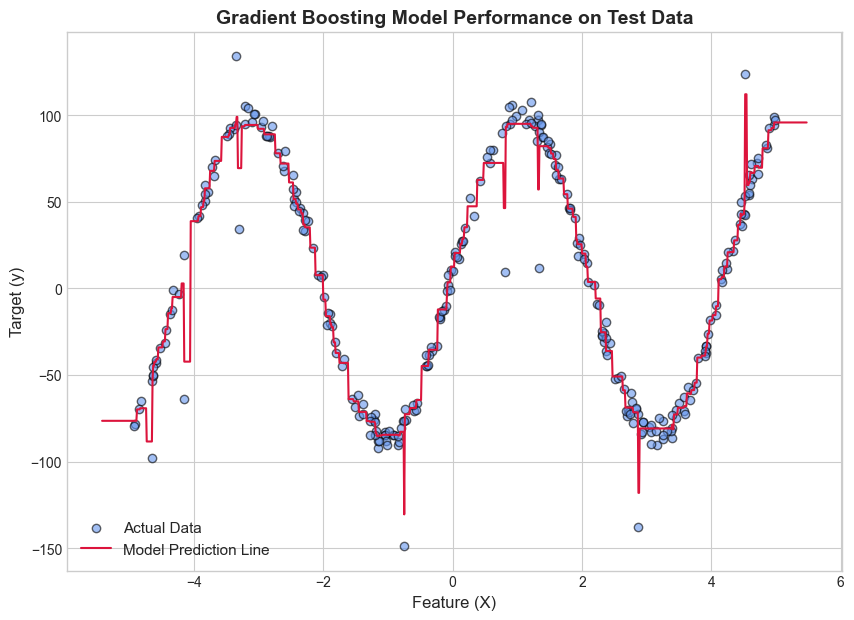

In [342]:
gbr_model = GradientBoostingRegressor(
    loss = "squared_error",
    learning_rate = 0.1,
    n_estimators = 100,
    subsample = 1.0,
    criterion = "friedman_mse",
    min_samples_split = 2,
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0,
    max_depth = 3,
    min_impurity_decrease = 0.0,
    init = None,
    random_state = None,
    max_features = None,
    alpha = 0.9,
    verbose = 0,
    max_leaf_nodes = None,
    warm_start = False,
    validation_fraction = 0.1,
    n_iter_no_change = None,
    tol = 1e-4,
    ccp_alpha = 0.0
)
gbr_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=gbr_model, print_results=True)
plot_sklearn_regression(gbr_model, X_nonlin, y_nonlin, title="Gradient Boosting Model Performance on Test Data")

----- 📈 Model Evaluation -----
MAE     4.7025
MSE    79.3806
RMSE    8.9096
R2      0.9815
-----------------------------


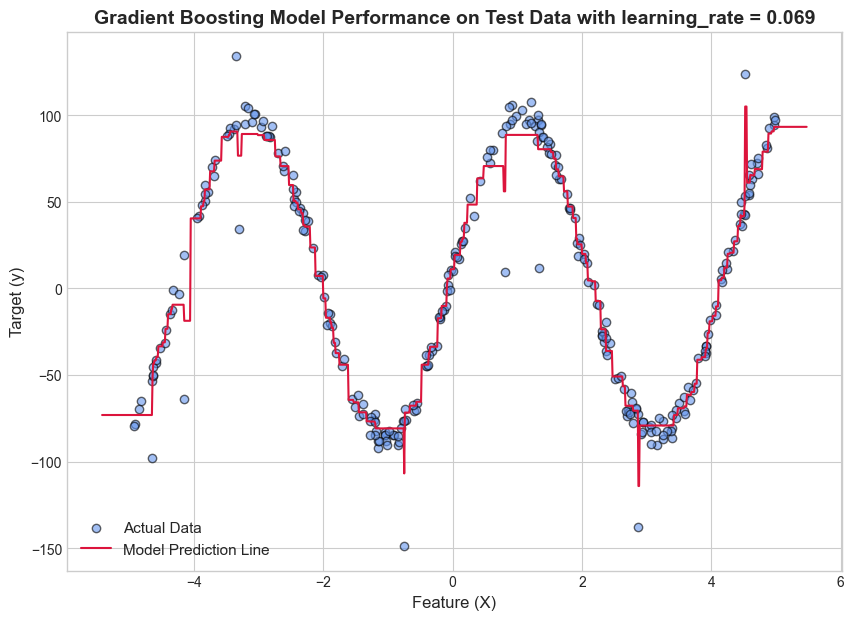

In [343]:
gbr_model = GradientBoostingRegressor(
    loss = "squared_error",
    learning_rate = 0.069,
    n_estimators = 100,
    subsample = 1.0,
    criterion = "friedman_mse",
    min_samples_split = 2,
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0,
    max_depth = 3,
    min_impurity_decrease = 0.0,
    init = None,
    random_state = None,
    max_features = None,
    alpha = 0.9,
    verbose = 0,
    max_leaf_nodes = None,
    warm_start = False,
    validation_fraction = 0.1,
    n_iter_no_change = None,
    tol = 1e-4,
    ccp_alpha = 0.0
)
gbr_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=gbr_model, print_results=True)
plot_sklearn_regression(gbr_model, X_nonlin, y_nonlin, title="Gradient Boosting Model Performance on Test Data with learning_rate = 0.069")

### 1.4.7. Playing with `VotingRegressor`

----- 📈 Model Evaluation -----
MAE     19.6242
MSE    493.8402
RMSE    22.2225
R2       0.8849
-----------------------------


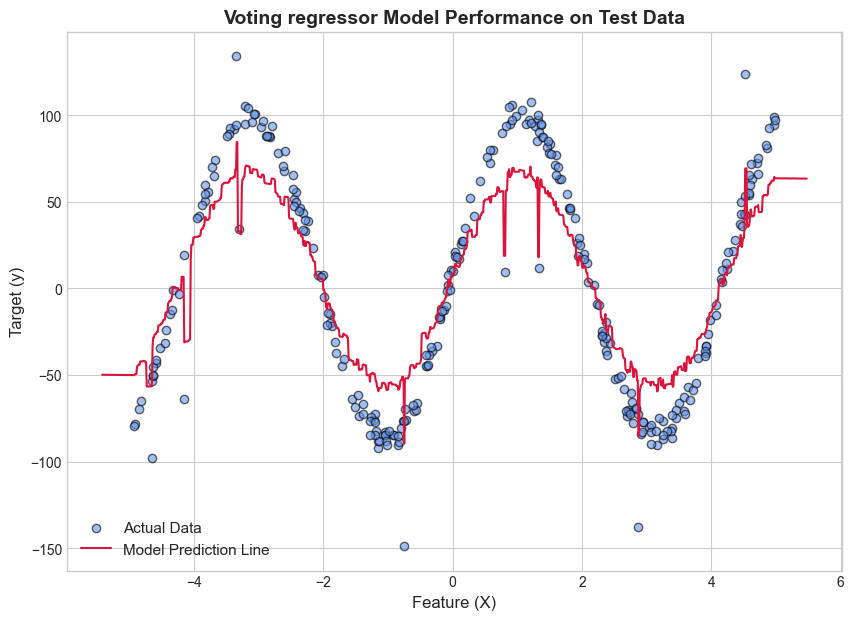

In [344]:
vr_model = VotingRegressor(
    estimators = [
        ("lr", LinearRegression()),
        ("dtr", DecisionTreeRegressor()),
        ("rfr", RandomForestRegressor())
    ],
    weights = None,
    n_jobs = None,
    verbose = 0
)
vr_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=vr_model, print_results=True)
plot_sklearn_regression(vr_model, X_nonlin, y_nonlin, title="Voting regressor Model Performance on Test Data")

----- 📈 Model Evaluation -----
MAE    1.4904
MSE    8.5115
RMSE   2.9175
R2     0.9980
-----------------------------


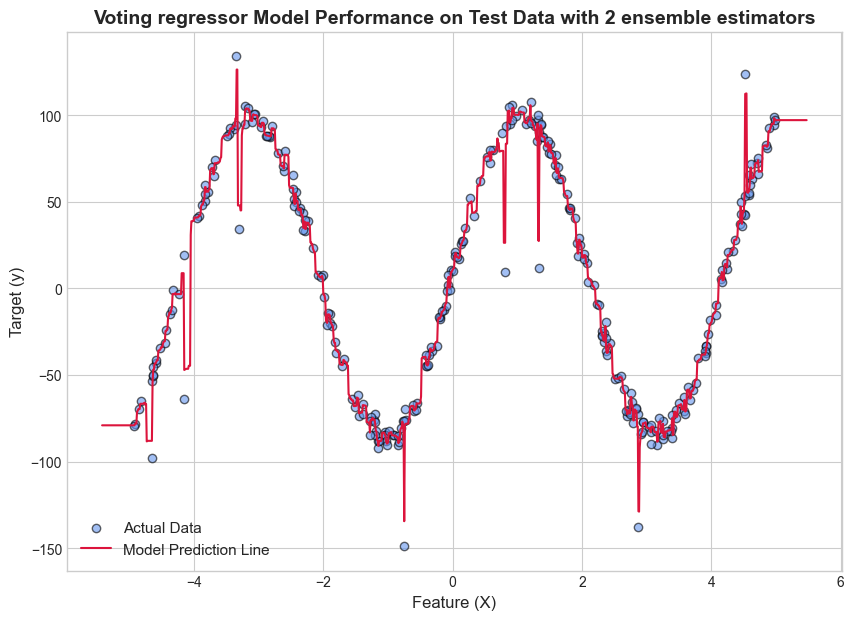

In [345]:
vr_model = VotingRegressor(
    estimators = [
        ("dtr", DecisionTreeRegressor()),
        ("rfr", RandomForestRegressor())
    ],
    weights = None,
    n_jobs = None,
    verbose = 0
)
vr_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=vr_model, print_results=True)
plot_sklearn_regression(vr_model, X_nonlin, y_nonlin, title="Voting regressor Model Performance on Test Data with 2 ensemble estimators")

### 1.4.8. Playing with `SVR (Support Vector Regression)`

----- 📈 Model Evaluation -----
MAE      56.1076
MSE    3973.6963
RMSE     63.0373
R2        0.0736
-----------------------------


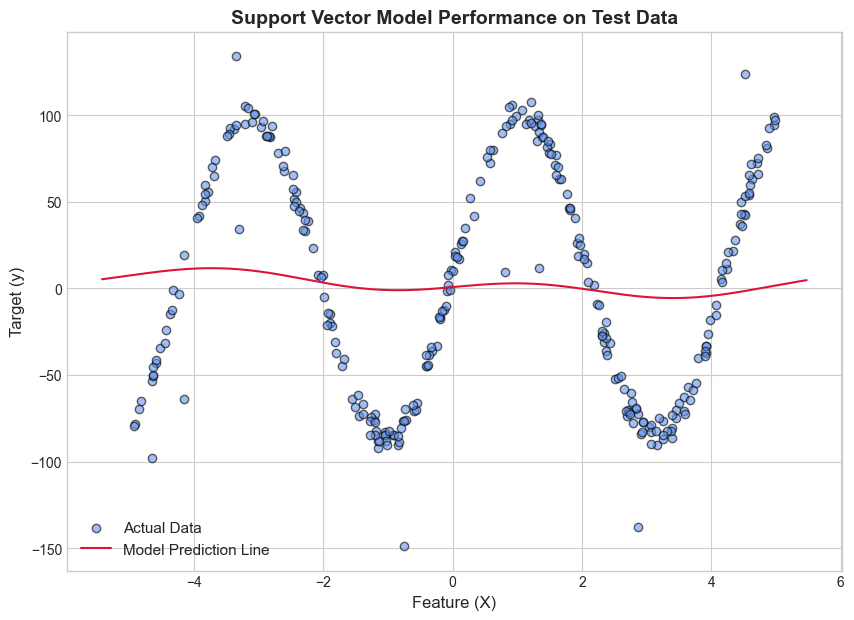

In [346]:
svr_model = SVR(
    kernel = 'rbf',
    degree = 3,
    gamma = 'scale',
    coef0 = 0.0,
    tol = 1e-4,
    C = 1.0,
    epsilon = 0.1,
    shrinking = True,
    cache_size = 200,
    verbose = 0,
    max_iter = -1,
)
svr_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=svr_model, print_results=True)
plot_sklearn_regression(svr_model, X_nonlin, y_nonlin, title="Support Vector Model Performance on Test Data")

----- 📈 Model Evaluation -----
MAE      9.7689
MSE    233.3278
RMSE    15.2751
R2       0.9456
-----------------------------


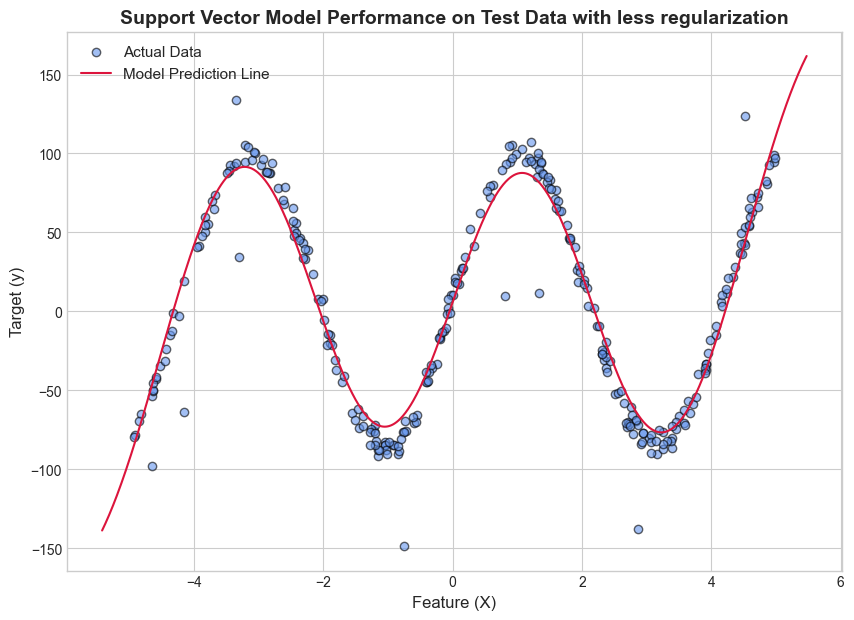

In [347]:
svr_model = SVR(
    kernel = 'rbf',
    degree = 3,
    gamma = 'scale',
    coef0 = 0.0,
    tol = 1e-4,
    C = 50.0,
    epsilon = 0.1,
    shrinking = True,
    cache_size = 200,
    verbose = 0,
    max_iter = -1,
)
svr_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=svr_model, print_results=True)
plot_sklearn_regression(svr_model, X_nonlin, y_nonlin, title="Support Vector Model Performance on Test Data with less regularization")

----- 📈 Model Evaluation -----
MAE      57.7081
MSE    4350.9588
RMSE     65.9618
R2       -0.0144
-----------------------------


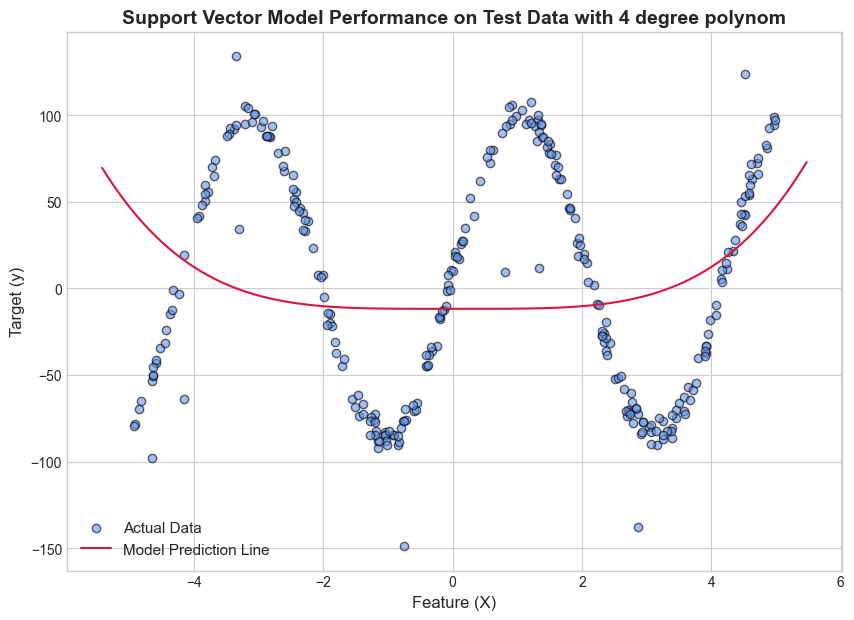

In [348]:
svr_model = SVR(
    kernel = 'poly',
    degree = 4,
    gamma = 'scale',
    coef0 = 0.0,
    tol = 1e-4,
    C = 50.0,
    epsilon = 0.1,
    shrinking = True,
    cache_size = 200,
    verbose = 0,
    max_iter = -1,
)
svr_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=svr_model, print_results=True)
plot_sklearn_regression(svr_model, X_nonlin, y_nonlin, title="Support Vector Model Performance on Test Data with 4 degree polynom")

----- 📈 Model Evaluation -----
MAE      52.9873
MSE    4501.9261
RMSE     67.0964
R2       -0.0496
-----------------------------


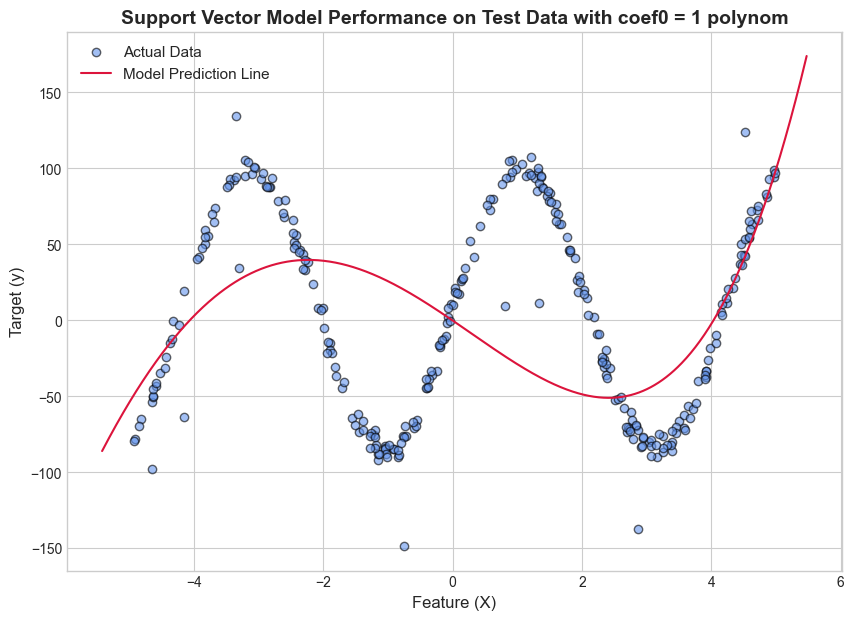

In [349]:
svr_model = SVR(
    kernel = 'poly',
    degree = 4,
    gamma = 'scale',
    coef0 = 1,
    tol = 1e-4,
    C = 50.0,
    epsilon = 0.1,
    shrinking = True,
    cache_size = 200,
    verbose = 0,
    max_iter = -1,
)
svr_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=svr_model, print_results=True)
plot_sklearn_regression(svr_model, X_nonlin, y_nonlin, title="Support Vector Model Performance on Test Data with coef0 = 1 polynom")

----- 📈 Model Evaluation -----
MAE      70.8753
MSE    8140.5088
RMSE     90.2248
R2       -0.8979
-----------------------------


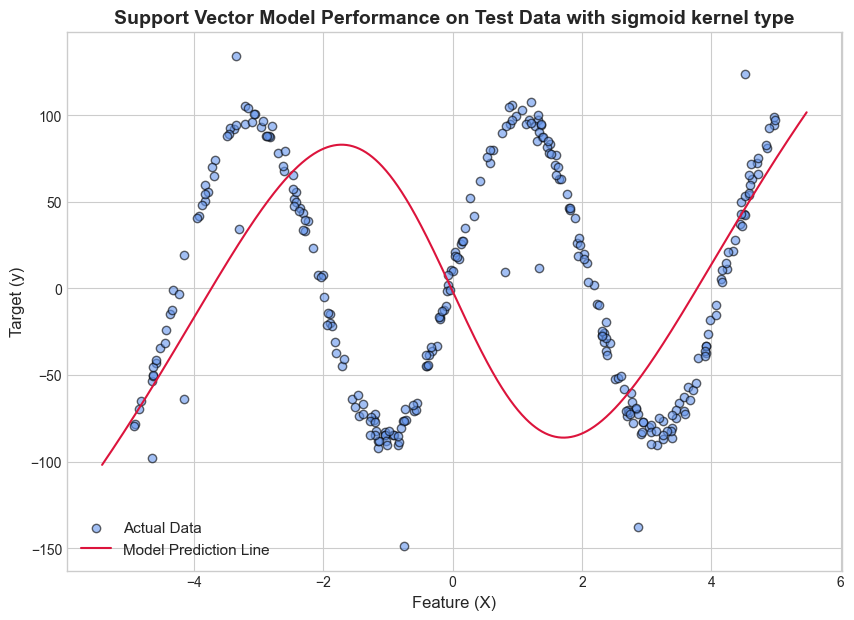

In [350]:
svr_model = SVR(
    kernel = 'sigmoid',
    degree = 3,
    gamma = 'scale',
    coef0 = 0.0,
    tol = 1e-4,
    C = 7.0,
    epsilon = 0.1,
    shrinking = True,
    cache_size = 200,
    verbose = 0,
    max_iter = -1,
)
svr_model.fit(X_nonlin, y_nonlin)

evaluate_regression_model(y_nonlin, X_nonlin, model=svr_model, print_results=True)
plot_sklearn_regression(svr_model, X_nonlin, y_nonlin, title="Support Vector Model Performance on Test Data with sigmoid kernel type")

# Section 2: experiments on real data

1. Choose any DataSet you like for you experiments (if you've chosen the same, consider that work must differ, otherwise both students will get 0 points for work).
2. Choose the top-3 methods (from `sklearn` library, or you can use other libraries (like `xgboost`) from the previous part.
2. Solve the regression problem in the same manner, as you used for.
    1. Load the data
    2. Do data visualization: correlation, feature distribution, etc.
    3. Do data analysis
    4. Do data correction
    5. Prepare data on usage with ML model: train, validation if necessary, test split; data convertion (to fix distribution or change data type to numeric); remove outliers.
    6. Tune hyperparameters of your model to get the best one.
    7. Train & test the final version of the model. Do conclusion.
3. Your main goal is tune hyperparameters of the chosen models.
4. Examples and template you can find in `ML_basic_course/lab_works/lab2/lab_2_example_plus_task.ipynb`. Or in [my GitHub repo's folder](https://github.com/VolDonets/ML_basics_course/tree/master/lab_works/lab_2)
5. Use that notebook as template, but remember your main goal is to tune hyperparameters of chosen models.

In [351]:
df = pd.read_csv(r"C:\Users\rodio\PycharmProjects\DataMining\ModelsDataAnalysis\Lab1\cleaned_OLX_EDA.csv")
df_photos = pd.read_csv(r"C:\Users\rodio\PycharmProjects\DataMining\ModelsDataAnalysis\Lab1\photos.csv")
df.head(10)

,id,title,url,description,price_uah,city_id,city_name,city_normalized_name,region_id,region_name,...,infrastructure_500_m,is_exchange,eoselia,number_of_rooms,property_type_appartments_sale_id,house_type_id,bathroom_id,repair_id,price_usd,multimedia
0,507269420,3-кімнатна квартира по Проспекту Перемоги 119А!!!,https://www.olx.ua/d/uk/obyavlenie/3-kmnatna-k...,Єдина 3-кімнатна квартира без ремонту в цьому ...,3136353.92,178,Чернігів,chernigov,23,Чернігівська область,...,"school, shop_kiosk, market, park, playground, ...",-1.0,0,3.0,11.0,0.0,1.0,5.0,70000.0,0.0
1,530436606,Продам 3 ком. квартиру .,https://www.olx.ua/d/uk/obyavlenie/prodam-3-ko...,Продам 3 ком. квартиру. Чистая и уютная. Не уг...,2419473.02,313,Вінниця,vinnitsa,24,Вінницька область,...,NaN,0.0,0,3.0,NaN,NaN,NaN,NaN,54000.0,NaN
2,544852462,Продається 3-х кімнатна квартира смт.Вендичани,https://www.olx.ua/d/uk/obyavlenie/prodatsya-3...,Продається 3-х кімнатна квартира с.Вендичани в...,246427.81,6971,Вендичани,vendichany,24,Вінницька область,...,NaN,0.0,0,3.0,NaN,NaN,2.0,NaN,5500.0,NaN
3,588959623,"2к.ЖК СімейнийКомфорт.Євроремонт,меблі,техніка",https://www.olx.ua/d/uk/obyavlenie/2k-zhk-smey...,2к.квартира у кращому житловому комплексі Сіме...,4122065.15,313,Вінниця,vinnitsa,24,Вінницька область,...,NaN,-1.0,0,2.0,NaN,NaN,NaN,NaN,92000.0,1.0
4,594642278,Продаю 3кім квартиру метро Печерська Терміново,https://www.olx.ua/d/uk/obyavlenie/prodayu-3km...,"Продаю 3 кім. елітну квартиру, вул. Коновальця...",13441516.80,268,Київ,kiev,25,Київська область,...,"bank_ATM, city_center, farmacy, hospital, kind...",0.0,0,3.0,10.0,0.0,3.0,1.0,300000.0,1.0
5,599814500,Продажа 3-х квартира центр ул. Пушкинская д. 4...,https://www.olx.ua/d/uk/obyavlenie/prodazha-3-...,Продам 3-х 4/6 Центр ул. Пушкинская (напротив ...,3360379.20,280,Харків,kharkov,8,Харківська область,...,"city_center, farmacy, hospital, kindergarten, ...",-1.0,0,3.0,NaN,0.0,2.0,2.0,75000.0,1.0
6,616127399,Продам 3 комнатную на Славянке. Улучшенной пла...,https://www.olx.ua/d/uk/obyavlenie/prodam-3-ko...,Продам трех комнатную квартиру. Сделанный полн...,2665900.83,313,Вінниця,vinnitsa,24,Вінницька область,...,NaN,0.0,0,3.0,NaN,1.0,NaN,NaN,59500.0,NaN
7,632220615,Квартира 2-х.к. від власника,https://www.olx.ua/d/uk/obyavlenie/kvartira-2-...,Продам 2 кімнатну квартиру в селі Вахнівка. 26...,309154.89,6847,Вахнівка,vahnovka,24,Вінницька область,...,NaN,0.0,0,2.0,NaN,NaN,1.0,NaN,6900.0,NaN
8,636737840,Продам квартиру 3-х комнатную СВОЯ на пр. Б. Х...,https://www.olx.ua/d/uk/obyavlenie/prodam-kvar...,Продам квартиру 3-х комнатную СВОЯ на пр. Б.Хм...,2688303.36,121,Дніпро,dnepr,21,Дніпропетровська область,...,NaN,1.0,0,3.0,3.0,3.0,2.0,2.0,60000.0,NaN
9,638581235,ПОСПЕШИТЕ! 1-к квартира ЖК Семейный комфорт. 4...,https://www.olx.ua/d/uk/obyavlenie/pospeshite-...,"1-к квартира в новострое ЖК ""Семейный комфорт""...",1971422.46,313,Вінниця,vinnitsa,24,Вінницька область,...,NaN,0.0,0,1.0,NaN,0.0,NaN,NaN,44000.0,NaN


In [352]:
df_photos.head(4)

,id,photo_link
0,925745435,https://ireland.apollo.olxcdn.com:443/v1/files...
1,925745435,https://ireland.apollo.olxcdn.com:443/v1/files...
2,925745435,https://ireland.apollo.olxcdn.com:443/v1/files...
3,925745435,https://ireland.apollo.olxcdn.com:443/v1/files...


In [353]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12053 entries, 0 to 12052
Data columns (total 47 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 12053 non-null  int64  
 1   title                              12053 non-null  str    
 2   url                                12053 non-null  str    
 3   description                        12053 non-null  str    
 4   price_uah                          12053 non-null  float64
 5   city_id                            12053 non-null  int64  
 6   city_name                          12053 non-null  str    
 7   city_normalized_name               12053 non-null  str    
 8   region_id                          12053 non-null  int64  
 9   region_name                        12053 non-null  str    
 10  region_normalized_name             12053 non-null  str    
 11  district_id                        5243 non-null   float64
 12  d

In [354]:
df.shape

(12053, 47)

In [355]:
c = ["number_of_rooms", "total_area", "kitchen_area", "floor", "total_floors", "property_type_appartments_sale", "region_name", "city_name", "house_type", "year_of_commissioning"]
df = df.loc[df["floor"] < 50]
df = df.loc[df["total_floors"] < 50]
df = df.loc[df["kitchen_area"] < 60]
df = df.loc[df["total_area"] < 260]
df = df.loc[df["price_usd"] < 750000]
df = df.loc[df["total_floors"] >= df["floor"]]
df.loc[df["total_floors"] > 40, "total_floors"] = 10

In [356]:
fig = px.histogram(df, x="region_name", y="price_usd", color="apartments_object_type", barmode="group", title="Sum of prices in regions by market")
fig.show()

In [357]:
fig = px.histogram(df, x="region_name", y="price_usd", color="floor", barmode="group", title="Sum of prices in regions by floor")
fig.show()

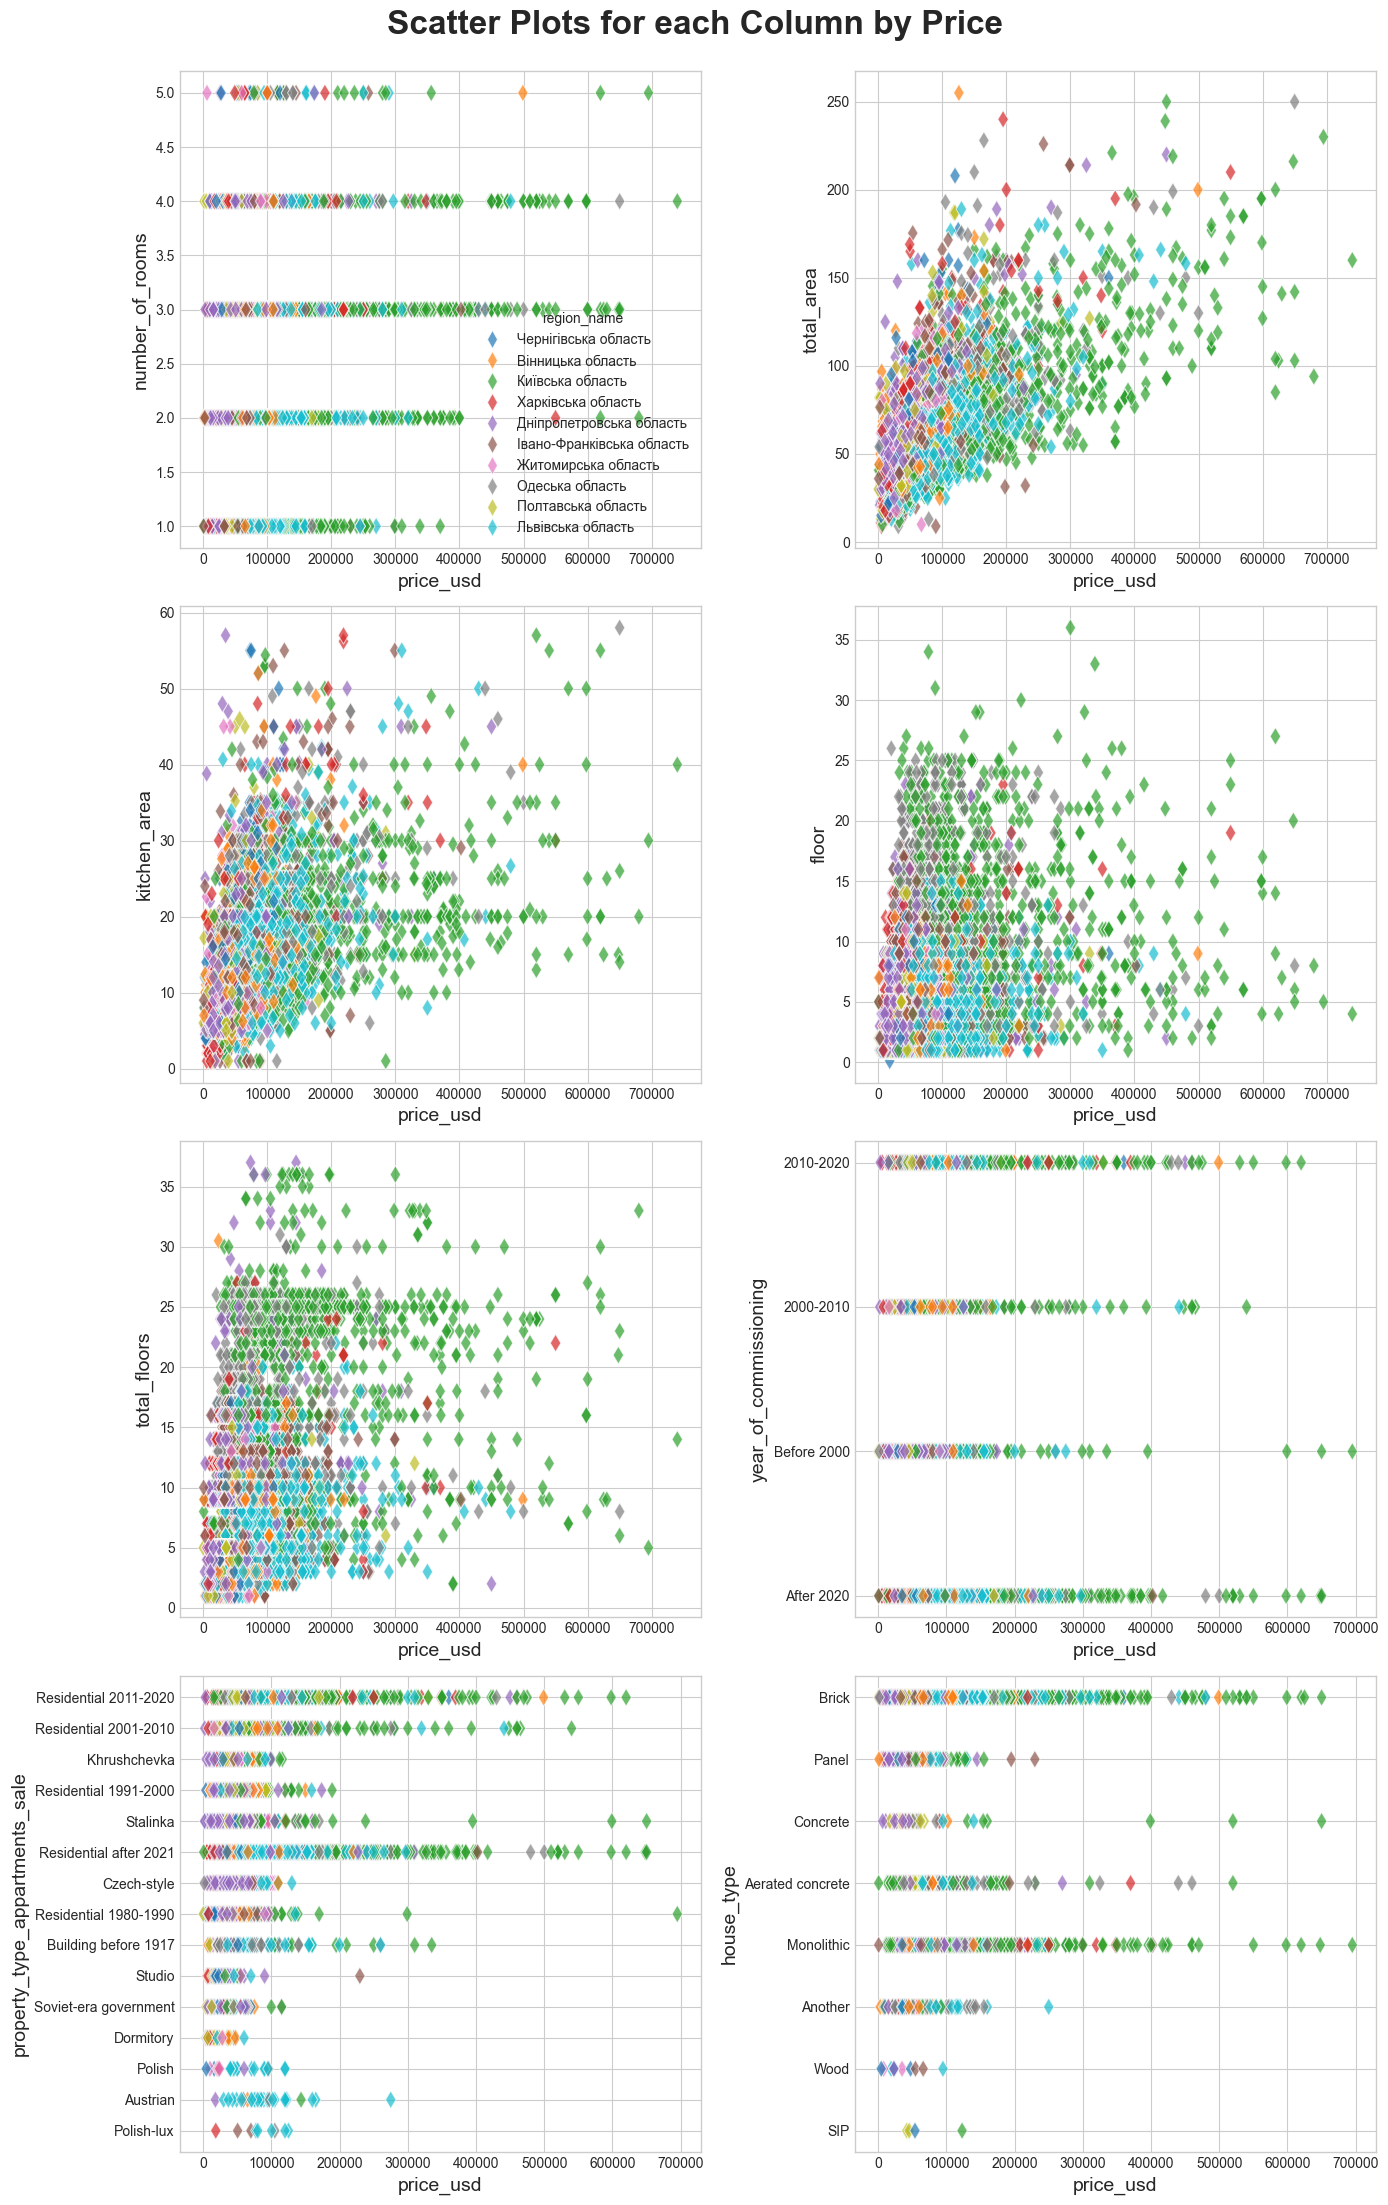

In [358]:
target_col = 'price_usd'

size=11
cols = ["number_of_rooms", "total_area", "kitchen_area", "floor", "total_floors", "year_of_commissioning", "property_type_appartments_sale", "house_type"]
n_cols = 2
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(size+3, size/n_cols*n_rows))
fig.suptitle(f'Scatter Plots for each Column by Price', fontsize=24, fontweight='bold', y=1)

axes_flat = axes.flatten()
legend = True
for i, col in enumerate(cols):
    ax = axes_flat[i]

    sns.scatterplot(df, y=df[col], x=df[target_col], s=80, alpha=0.7, hue="region_name", ax=ax, marker='d', legend=legend)

    ax.set_ylabel(f'{col}', fontsize=14)
    ax.set_xlabel(f'{target_col}', fontsize=14)
    legend = False

plt.tight_layout()
plt.show()

<Figure size 800x800 with 0 Axes>

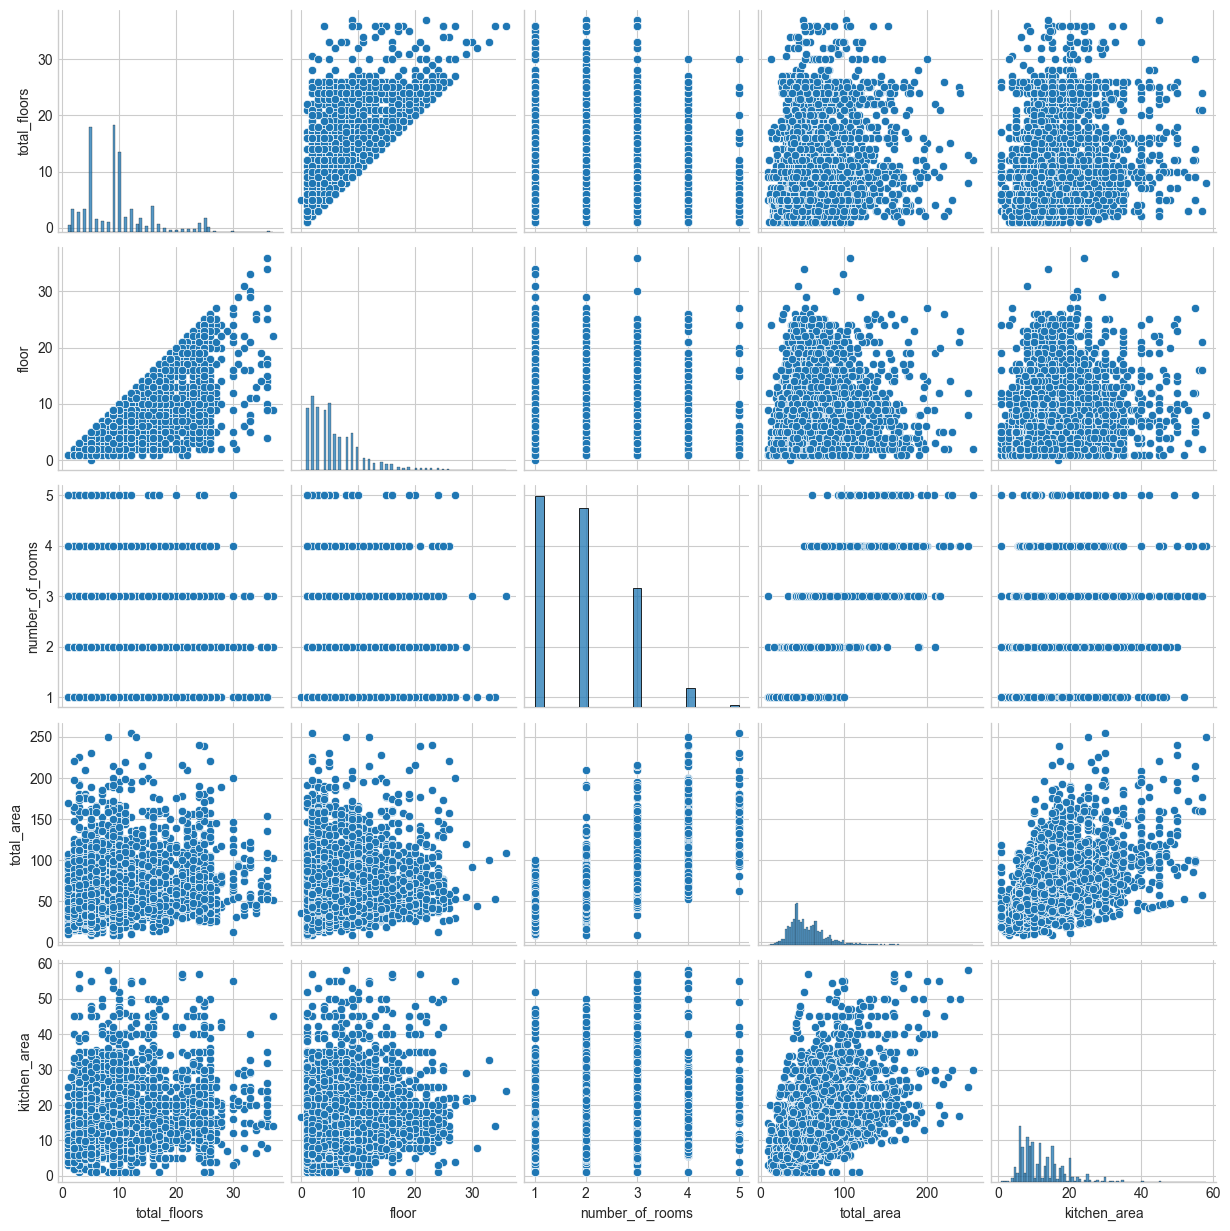

In [359]:
plt.figure(figsize=(8, 8))
sns.pairplot(df[["total_floors", "floor", "number_of_rooms", "total_area", "kitchen_area"]], diag_kind='hist')
plt.show()

In [360]:
new_cols = ["total_photos", "in_centre",  "not_kitchen_area", "floor_height", "time_on_market", "primary_market", "words_in_title", "words_in_description", "top_floor", "first_floor"]

counts = df_photos["id"].value_counts()
df["total_photos"] = df.join(counts, how='left', on="id")["count"]
df["total_photos"] = df["total_photos"].fillna(0)

centres = ["ivano-frankovsk", "kiev", "odessa", "kharkov", "chernigov", "vinnitsa", "poltava", "lvov", "dnepr", "zhitomir"]
df["in_centre"] = df["city_normalized_name"].isin(centres)

df["not_kitchen_area"] = df["total_area"] - df["kitchen_area"]

df["floor_height"] = df["floor"] / df["total_floors"]

today = pd.Timestamp.today(tz="UTC").normalize()
df["created_time_datetime"] = pd.to_datetime(df["created_time"], utc=True)
df["time_on_market"] = (today - df["created_time_datetime"]).dt.days

df["primary_market"] = df["apartments_object_type"] == "primary_market"

df["words_in_title"] = df["title"].apply(lambda x: len(re.findall(r'\w+', x)))
df["words_in_description"] = df["description"].apply(lambda x: len(re.findall(r'\w+', x)))

df["top_floor"] = df["floor"] == df["total_floors"]
df["first_floor"] = df["floor"] <= 1

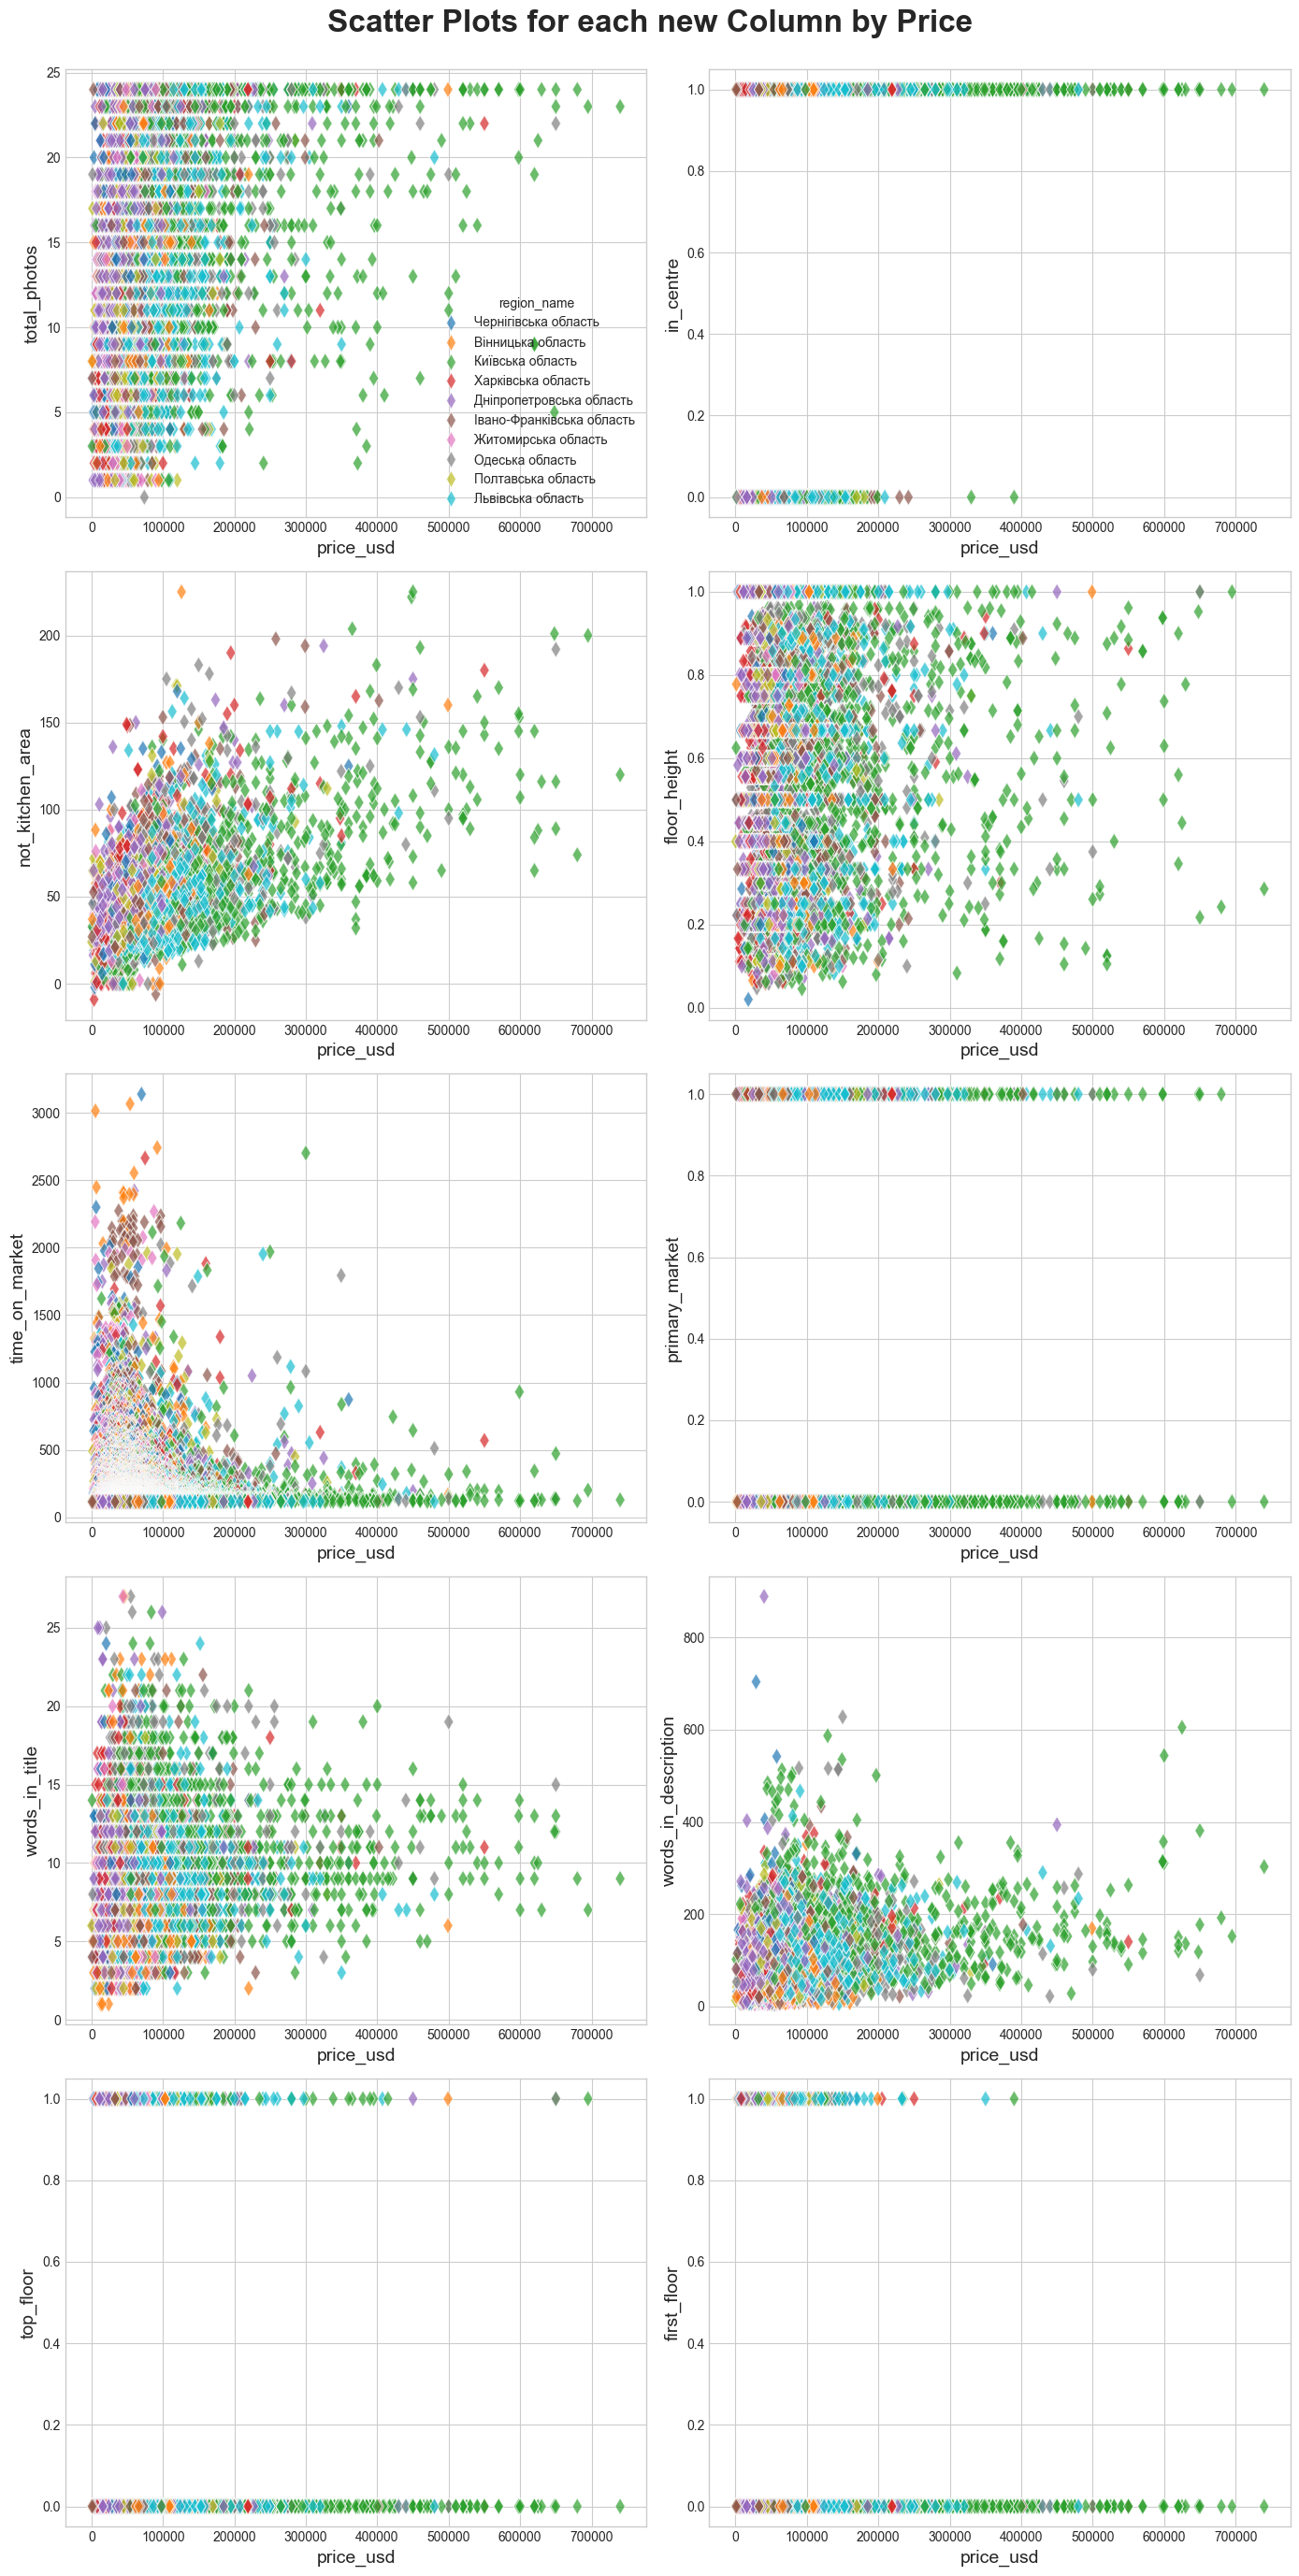

In [361]:
target_col = 'price_usd'

size=11
n_cols = 2
n_rows = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(size+3, size/n_cols*n_rows))
fig.suptitle(f'Scatter Plots for each new Column by Price', fontsize=24, fontweight='bold', y=1)

axes_flat = axes.flatten()
legend = True
for i, col in enumerate(new_cols):
    ax = axes_flat[i]

    sns.scatterplot(df, y=df[col], x=df[target_col], s=80, alpha=0.7, hue="region_name", ax=ax, marker='d', legend=legend)

    ax.set_ylabel(f'{col}', fontsize=14)
    ax.set_xlabel(f'{target_col}', fontsize=14)
    legend = False

plt.tight_layout()
plt.show()

In [362]:
df.info()

<class 'pandas.DataFrame'>
Index: 11981 entries, 0 to 12052
Data columns (total 58 columns):
 #   Column                             Non-Null Count  Dtype              
---  ------                             --------------  -----              
 0   id                                 11981 non-null  int64              
 1   title                              11981 non-null  str                
 2   url                                11981 non-null  str                
 3   description                        11981 non-null  str                
 4   price_uah                          11981 non-null  float64            
 5   city_id                            11981 non-null  int64              
 6   city_name                          11981 non-null  str                
 7   city_normalized_name               11981 non-null  str                
 8   region_id                          11981 non-null  int64              
 9   region_name                        11981 non-null  str            

### Preparing dataset for training

In [363]:
df = df.drop(columns=["id", "title", "url", "description", "price_uah", "city_id", "city_name", "region_id", "region_name", "district_id", "district_name", "created_time", "last_refresh_time", "apartments_object_type", "zkh", "appliances", "multimedia_2", "comfort", "communications", "ecosystem_1_km", "cooperate", "infrastructure_500_m", "is_exchange", "eoselia", "property_type_appartments_sale_id", "house_type_id", "bathroom_id", "repair_id", "multimedia", "created_time_datetime"])

In [364]:
df.loc[df["apartments_dev_type"].isna(), "apartments_dev_type"] = "unknown"
df.loc[df["property_type_appartments_sale"].isna(), "property_type_appartments_sale"] = "unknown"
df.loc[df["house_type"].isna(), "house_type"] = "unknown"
df.loc[df["year_of_commissioning"].isna(), "year_of_commissioning"] = "unknown"
df.loc[df["bathroom"].isna(), "bathroom"] = "unknown"
df.loc[df["heating"].isna(), "heating"] = "unknown"
df.loc[df["repair"].isna(), "repair"] = "unknown"
df.loc[df["furnish"].isna(), "furnish"] = "unknown"
df.loc[df["layout"].isna(), "layout"] = "unknown"

df["in_centre"] = df["in_centre"].astype(float)
df["primary_market"] = df["primary_market"].astype(float)
df["top_floor"] = df["top_floor"].astype(float)
df["first_floor"] = df["first_floor"].astype(float)

In [365]:
df.info()

<class 'pandas.DataFrame'>
Index: 11981 entries, 0 to 12052
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   city_normalized_name            11981 non-null  str    
 1   region_normalized_name          11981 non-null  str    
 2   commission                      11981 non-null  float64
 3   property_type_appartments_sale  11981 non-null  str    
 4   floor                           11981 non-null  float64
 5   total_floors                    11981 non-null  float64
 6   total_area                      11981 non-null  float64
 7   kitchen_area                    11981 non-null  float64
 8   house_type                      11981 non-null  str    
 9   apartments_dev_type             11981 non-null  str    
 10  bathroom                        11981 non-null  str    
 11  heating                         11981 non-null  str    
 12  repair                          11981 non-null  

In [366]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [367]:
df_ml = df.copy()

In [368]:
onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first").set_output(transform="pandas")
onehot_encoded = onehot_encoder.fit_transform(df_ml[["region_normalized_name", "house_type", "apartments_dev_type", "bathroom", "heating", "repair", "furnish", "year_of_commissioning", "layout", "property_type_appartments_sale"]])
df_ml = pd.concat([df_ml, onehot_encoded], axis=1).drop(columns=["region_normalized_name", "house_type", "apartments_dev_type", "bathroom", "heating", "repair", "furnish", "year_of_commissioning", "layout", "property_type_appartments_sale"])

In [369]:
df_ml.shape

(11981, 88)

In [370]:
target = 'price_usd'
X = df_ml.drop(columns=[target, "city_normalized_name"])

corr_matrix = X.corr().abs()

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.9
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]

print(f"Cols to drop: {to_drop}")

df_ml = df_ml.drop(columns=to_drop)

Cols to drop: ['not_kitchen_area', 'property_type_appartments_sale_Residential 2011-2020', 'property_type_appartments_sale_Residential after 2021', 'property_type_appartments_sale_unknown']


In [371]:
X = df_ml.drop(target, axis=1)
y = df_ml[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=STUDENT_NO)

In [372]:
city_counts = X_train["city_normalized_name"].value_counts()
big_cities = city_counts[city_counts >= 40].index.tolist()

def encode_cities(df, column):
    cities_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first").set_output(transform="pandas")
    df.loc[~df[column].isin(big_cities), column] = "other"
    cities = cities_encoder.fit_transform(df[[column]])
    return pd.concat([df, cities], axis=1).drop(columns=[column])

In [373]:
X_train = encode_cities(X_train, "city_normalized_name")
X_train.shape

(9584, 103)

In [374]:
minmax_scaler = MinMaxScaler(clip=True)
standard_scaler = StandardScaler()

minmax_cols = ["total_photos", "number_of_rooms"]
standard_cols = ["floor", "total_floors", "total_area", "kitchen_area", "time_on_market", "words_in_title", "words_in_description"]

minmax_scaler.fit(X_train[minmax_cols])
X_train[minmax_cols] = minmax_scaler.transform(X_train[minmax_cols])

standard_scaler.fit(X_train[standard_cols])
X_train[standard_cols] = standard_scaler.transform(X_train[standard_cols])
X_train.head(10)

,commission,floor,total_floors,total_area,kitchen_area,number_of_rooms,total_photos,in_centre,floor_height,time_on_market,...,city_normalized_name_krivoyrog,city_normalized_name_lvov,city_normalized_name_odessa,city_normalized_name_other,city_normalized_name_poltava,city_normalized_name_sofievskaya-borschagovka,city_normalized_name_sokolniki_38727,city_normalized_name_vinniki_37885,city_normalized_name_vinnitsa,city_normalized_name_zhitomir
3893,0.0,-0.194085,0.056516,-0.090678,-0.396674,0.25,0.708333,1.0,0.500000,-0.200284,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9071,0.0,0.475984,2.438873,2.446084,1.308924,0.50,0.375000,1.0,0.333333,-0.416871,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3258,0.0,0.475984,-0.113653,-0.573870,0.171859,0.00,0.708333,1.0,0.888889,-0.123194,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3435,0.0,-0.640798,-0.964495,-0.573870,-0.965207,0.25,0.291667,1.0,0.750000,-0.152561,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3429,0.0,-0.640798,0.056516,-0.734935,1.024657,0.00,1.000000,0.0,0.300000,-0.152561,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2417,0.0,-1.087511,-0.113653,0.231451,-0.680940,0.50,0.500000,1.0,0.111111,0.078709,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1960,0.0,-0.640798,0.056516,0.432781,-0.538807,0.50,0.416667,0.0,0.300000,0.280612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3928,0.0,0.029271,1.417863,-0.453072,1.024657,0.00,0.875000,1.0,0.333333,-0.200284,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6869,0.0,-0.640798,-0.113653,-0.529578,1.024657,0.00,0.291667,1.0,0.333333,-0.391174,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2743,1.0,-0.194085,-0.794326,-0.493338,-0.112408,0.25,0.708333,1.0,1.000000,-0.024078,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [375]:
X_test = encode_cities(X_test, "city_normalized_name")
X_test[minmax_cols] = minmax_scaler.transform(X_test[minmax_cols])
X_test[standard_cols] = standard_scaler.transform(X_test[standard_cols])

### Training Models

In [406]:
models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(C=50.0),
    "Gradient Boosting": GradientBoostingRegressor(),
    "KNeighbors": KNeighborsRegressor(),
    "Random Forest": RandomForestRegressor(random_state=STUDENT_NO, n_jobs=-1)
}

metrics_report = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    
    evaluate_regression_model(y_test, X_test, model, model_name=model_name)


----- 📈 Linear Regression Evaluation -----
MAE         18920.7014
MSE    1085694305.3575
RMSE        32949.8757
R2              0.7211
-----------------------------
----- 📈 SVR Evaluation -----
MAE         30593.2594
MSE    3520013288.1875
RMSE        59329.6999
R2              0.0959
-----------------------------
----- 📈 Gradient Boosting Evaluation -----
MAE        16151.3402
MSE    867204961.7347
RMSE       29448.3440
R2             0.7773
-----------------------------
----- 📈 KNeighbors Evaluation -----
MAE         18905.5999
MSE    1290357072.4134
RMSE        35921.5405
R2              0.6686
-----------------------------
----- 📈 Random Forest Evaluation -----
MAE        15457.0743
MSE    916545656.5341
RMSE       30274.5051
R2             0.7646
-----------------------------


#### Середнє значення цільової змінної для розуміння масштабів помилки:

In [403]:
y_test.mean

np.float64(71367.22399211135)

### Hyperparameters fine-tuning 

In [407]:
from sklearn.model_selection import GridSearchCV

rfr_model = RandomForestRegressor(random_state=STUDENT_NO, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [1.0, 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=rfr_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_squared_error'
)

grid_search.fit(X_train, y_train)
print("Кращі параметри:", grid_search.best_params_)
print("Найкраща модель:", grid_search.best_estimator_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Кращі параметри: {'max_depth': 30, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Найкраща модель: RandomForestRegressor(max_depth=30, n_estimators=300, n_jobs=-1,
                      random_state=20)


In [409]:
best_rfr_model = RandomForestRegressor(max_depth=30, n_estimators=300, n_jobs=-1, random_state=STUDENT_NO)

best_rfr_model.fit(X_train, y_train)
evaluate_regression_model(y_test, X_test, best_rfr_model)

----- 📈 Model Evaluation -----
MAE        15378.9799
MSE    909059512.8386
RMSE       30150.6138
R2             0.7665
-----------------------------


{'MAE': 15378.979872936376,
 'MSE': 909059512.8385702,
 'RMSE': np.float64(30150.61380533687),
 'R2': 0.7665061547528191}

In [410]:
gbr_model = GradientBoostingRegressor(random_state=STUDENT_NO)

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': [None, 'sqrt']
}

grid_search = GridSearchCV(
    estimator=gbr_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_squared_error'
)

grid_search.fit(X_train, y_train)
print("Кращі параметри:", grid_search.best_params_)
print("Найкраща модель:", grid_search.best_estimator_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Кращі параметри: {'learning_rate': 0.05, 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 0.8}
Найкраща модель: GradientBoostingRegressor(learning_rate=0.05, max_depth=7, max_features='sqrt',
                          n_estimators=300, random_state=20, subsample=0.8)


In [415]:
gbr_best_model = GradientBoostingRegressor(learning_rate=0.05, max_depth=7, max_features='sqrt', n_estimators=300, random_state=STUDENT_NO, subsample=0.8)

gbr_best_model.fit(X_train, y_train)
evaluate_regression_model(y_test, X_test, gbr_best_model)

----- 📈 Model Evaluation -----
MAE        14374.2231
MSE    747981665.7895
RMSE       27349.2535
R2             0.8079
-----------------------------


{'MAE': 14374.22305049068,
 'MSE': 747981665.7894595,
 'RMSE': np.float64(27349.25347773609),
 'R2': 0.8078793380928113}

### За замовчування Gradient Boosting Regressor впорався найкраще, після підбору гіперпараметрів збільшив показник R2 на 0.03. 
### Найкращими гіперпараметрами для цієї моделі вийшли: 
* **`learning_rate = 0.05`** оптимальна швидкість навчання, що забезпечує зважене та поступове оновлення вагів.
* **`max_depth = 7`** максимальна глибина дерев, яка дозволила моделі охопити складні нелінійні зв'язки в даних.
* **`max_features = 'sqrt'`** використання квадратного кореня від загальної кількості ознак для кожного розбиття, що підвищує загальність моделі.
* **`n_estimators = 300`** кількість дерев у бустинговому ансамблі, достатня для збіжності та досягнення високої точності.
* **`subsample = 0.8`** частка вибірки для навчання кожного дерева, що зменшує ризик перенавчання.
* **`random_state = STUDENT_NO`** фіксація випадкового зерна для гарантування відтворюваності результатів експерименту.